## Papers Relevant to This Topic

- **Kapsch et al. (2016)**  
  *The Effect of Downwelling Longwave and Shortwave Radiation on Arctic Summer Sea Ice*  
  https://doi.org/10.1175/JCLI-D-15-0238.1  

- **Sicard et al. (2023)**  
  *Similarities and Differences in Arctic Sea-Ice Loss During the Solar-Forced Last Interglacial Warming (127 Kyr BP) and CO₂-Forced Future Warming*  
  https://doi.org/10.1029/2023GL104782  

- **Sicard et al. (2025)**  
  *Variations in Arctic Ocean Dynamics and Hydrography Under 127 ka Last Interglacial Conditions and Future Warming*  
  https://doi.org/10.1029/2025PA005247  

- **Drobot et al. (2006)**  
  *A Long-Range Forecast of Arctic Summer Sea-Ice Minimum Extent*  
  https://doi.org/10.1029/2006GL026216  

- **Murto et al. (2026)**  
  *Characteristics of Springtime Surface Energy Budget Anomalies and Their Relation to Arctic Melt Onset Dates*  
  https://doi.org/10.1175/JCLI-D-25-0382.1  

  Highlights that melt onset (and thus Sep SIA) are governed by anomalies in the surface energy balance. 

- **Murto et al. (2023)**  
  *Extreme Surface Energy Budget Anomalies in the High Arctic in Winter*  
  https://doi.org/10.1175/JCLI-D-22-0209.1  

- **Kim et al. (2021)**  
  *A Regional Seasonal Forecast Model of Arctic Minimum Sea Ice Extent: Reflected Solar Radiation versus Late Winter Coastal Divergence*  
  https://doi.org/10.1175/JCLI-D-20-0846.1  

- **Huang et al. (2019)**  
  *Radiative Control of the Interannual Variability of Arctic Sea Ice*  
  https://doi.org/10.1029/2019GL084204  

- **Kapsch et al. (2014)**  
  *The Importance of Spring Atmospheric Conditions for Predictions of the Arctic Summer Sea Ice Extent*  
  https://doi.org/10.1002/2014GL060826  
  
  Shows that predictions of September sea ice can be based on only two atmospheric variables (ignoring ocean etc).
  Achieves ok prediction from several months out, but highlights the difficulty of going longer.
  This reinforces the result we get here, since the peak of importance is June / July. 

  Also goes in to detail about the (negative) correlation between LW and SW radiation.
  This is good as it reinforces the benefit of using a paleo experiment where SW is orbitally forced. 

- **Kapsch et al. (2013)**  
  *Springtime Atmospheric Energy Transport and the Control of Arctic Summer Sea-Ice Extent*  
  https://doi.org/10.1038/nclimate1884  

In [1]:
###To do for the team
#Plot Paleo vs Crossing energy without the weighting function
#Show plots without model weighting function, and without the two outliers
#Make map plots for the different models at a given SIA (not their own lig127k, but a specified number, e.g. 1Mkm2, 1.4Mkm2, 2Mkm2)

#Look at the literature for the cloud feedback, and why the energy profile is as it is under GHG conditions.
#It seems like like under conditions of reduced sea ice, the important months move later in the year. 
#This would provide some protection, as the peak occurs when the energy anomalies are smaller in GHG conditions. 


In [4]:
###Regridding logic in terminal:
input_string = 'tos_Omon_CESM2_piControl_r1i1p1f1_gr_000101-120012.nc'
output_string = input_string.replace('gn', 'cdo')
full_string = 'cdo remapbil,r360x180 ' + input_string + ' ' + output_string
print(full_string)

cdo remapbil,r360x180 tos_Omon_CESM2_piControl_r1i1p1f1_gr_000101-120012.nc tos_Omon_CESM2_piControl_r1i1p1f1_gr_000101-120012.nc


In [4]:
###Zipping logic in terminal:
input_string = 'tos_Omon_IPSL-CM6A-LR_lig127k_r1i1p1f1_gn_185001-239912.nc'
temp_string = input_string.replace('.nc', '_temp.nc')
full_string = f'cdo -z zip_3 copy {input_string} {temp_string} && mv {temp_string} {input_string}'
print(full_string)


cdo -z zip_3 copy tos_Omon_IPSL-CM6A-LR_lig127k_r1i1p1f1_gn_185001-239912.nc tos_Omon_IPSL-CM6A-LR_lig127k_r1i1p1f1_gn_185001-239912_temp.nc && mv tos_Omon_IPSL-CM6A-LR_lig127k_r1i1p1f1_gn_185001-239912_temp.nc tos_Omon_IPSL-CM6A-LR_lig127k_r1i1p1f1_gn_185001-239912.nc


In [9]:
# remap and zip in one step
input_string = 'tos_Omon_NESM3_piControl_r1i1p1f1_gn_100001-149912.nc'
output_string = input_string.replace('_gn_', '_cdo_').replace('_gr_','_cdo_')

full_string = (
    f'in="{input_string}"; '
    f'out="{output_string}"; '
    f'cdo -s -z zip_3 remapbil,r360x180 "$in" "$out"'
)

print(full_string)

in="tos_Omon_NESM3_piControl_r1i1p1f1_gn_100001-149912.nc"; out="tos_Omon_NESM3_piControl_r1i1p1f1_cdo_100001-149912.nc"; cdo -s -z zip_3 remapbil,r360x180 "$in" "$out"


In [ ]:
#String to check for missing variables in all models and experiments. 
#Need to be in the main data directory for this to work, and the models need to be in their own subdirectories.

#String to check for missing variables in a specfic model
# MODEL=NESM3; VARS="rsds rsus rlds rlus rsdscs rldscs hfls hfss siconc sithick tos clt"; for expdir in "$MODEL"/*/; do [ -d "$expdir" ] || continue; exp=$(basename "$expdir"); missing=""; for var in $VARS; do ls "$expdir"/"${var}"_*.nc >/dev/null 2>&1 || missing="$missing $var"; done; [ -z "$missing" ] && echo "$MODEL/$exp: all present" || echo "$MODEL/$exp missing:$missing"; done

#String to check for missing variables in a specfic model, but only for the regridded files
# MODEL=NESM3; VARS="siconc sithick tos"; for expdir in "$MODEL"/*/; do [ -d "$expdir" ] || continue; exp=$(basename "$expdir"); missing=""; for var in $VARS; do ls "$expdir"/"${var}"*_cdo_*.nc >/dev/null 2>&1 || missing="$missing $var"; done; [ -z "$missing" ] && echo "$MODEL/$exp: all present" || echo "$MODEL/$exp missing:$missing"; done

In [4]:
# Import various python packages

import iris
import iris.plot as iplt
import iris.quickplot as qplt
import iris.coord_categorisation as icc
from iris.time import PartialDateTime
import iris.analysis

import xarray as xr

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pandas as pd

import os
import warnings 
import io

import cartopy.io.shapereader as shpreader


from matplotlib.path import Path
import matplotlib.patches as mpatches
import calendar
from matplotlib.colors import Normalize, ListedColormap
from matplotlib.cm import get_cmap

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler

from scipy.optimize import minimize
from scipy.stats import norm

import operator

warnings.filterwarnings('ignore') 

In [ ]:

def get_crossing_big_dict(models, paleo_big_dict, transient_big_dict, sia_crossing=None, window=10):
    

    crossing_big_dict = {}
    for model in models:
        
        if sia_crossing is None:
            paleo_siconc_anom = paleo_big_dict[model][ts_to_use]['siconc'].extract(iris.Constraint(month=paleo_month)).collapsed('year', iris.analysis.MEAN).data / 1e14
        else:
            paleo_siconc_anom = sia_crossing
            
        transient_siconc_ts_anom = transient_big_dict[model][ts_to_use]['siconc'].extract(iris.Constraint(month=transient_month)) / 1e14
        
        transient_min =  transient_siconc_ts_anom.data

        transient_min_rolling = pd.Series(transient_min).rolling(window=window, center=True).mean()

        n_years = transient_min_rolling.shape[0]
        years = np.arange(n_years) + 1

        crossing_mask = transient_min_rolling.to_numpy() <= paleo_siconc_anom

        if not np.any(crossing_mask):
            print(f"{model}: no crossing found")
            continue

        sia_crossing_idx = np.where(crossing_mask)[0][0]
        sia_crossing_year = years[sia_crossing_idx]
        #sia_crossing_year = years[transient_min_rolling <= paleo_siconc_anom][0]

        print(f'{model} paleo Aug siconc anomaly: {paleo_siconc_anom:.2f}, transient crossing year: {sia_crossing_year}')


        transient_siconc_ts_anom = (
        transient_big_dict[model][ts_to_use]['siconc']
        .extract(iris.Constraint(month=transient_month))
        / 1e14
        )

        transient_min = transient_siconc_ts_anom.data
        years_coord = transient_siconc_ts_anom.coord('year').points

        transient_min_rolling = (
            pd.Series(transient_min, index=years_coord)
            .rolling(window=window, center=True)
            .mean()
        )

        crossing_mask = transient_min_rolling.to_numpy() <= paleo_siconc_anom

        if not np.any(crossing_mask):
            print(f"{model}: no crossing found")
            continue

        crossing_year_value = transient_min_rolling.index[np.where(crossing_mask)[0][0]]
        
        crossing_cubes_dict = {}
        crossing_ts_dict = {}
        crossing_clim_dict = {}
        crossing_anom_ts_dict = {}
        crossing_anom_clim_dict = {}
        
        for var in var_list:

            # unique_years = transient_big_dict[model][ts_to_use]['siconc'].coord('year').points
            # crossing_year_value = unique_years[sia_crossing_year - 1]

            half_window = window // 2
            year_constraint = iris.Constraint(
                year=lambda y: crossing_year_value - half_window <= y < crossing_year_value + half_window
                )

            cube = transient_big_dict[model]['cubes'][var].extract(year_constraint)
            crossing_cubes_dict[var] = cube

            ts = transient_big_dict[model]['ts'][var].extract(year_constraint)
            crossing_ts_dict[var] = ts

            anom_ts = transient_big_dict[model]['anom_ts'][var].extract(year_constraint)
            crossing_anom_ts_dict[var] = anom_ts


        crossing_clim_dict = get_clim_dict_from_ts_dict(crossing_ts_dict)
        crossing_anom_clim_dict = get_clim_dict_from_ts_dict(crossing_anom_ts_dict)
        
        crossing_big_dict[model] = {'cubes': crossing_cubes_dict,
                                'ts': crossing_ts_dict,
                                'clim': crossing_clim_dict,
                                'anom_ts': crossing_anom_ts_dict,
                                'anom_clim': crossing_anom_clim_dict,
                                }
    return crossing_big_dict


In [5]:
import sys
sys.path.append('..')

from Cube_Functions import *
from Plot_Functions import *
from Climate_Functions import *
from Stats_Functions import *
print('Finished loading libraries and functions')

#clean up namespace
del sys

Finished loading libraries and functions


In [6]:
models = [    
    'ACCESS-ESM1-5',
    'AWI-ESM-1-1-LR',
    'CESM2',
    'CNRM-CM6-1',
    'FGOALS-g3',
    'IPSL-CM6A-LR',
    'MIROC-ES2L',
    'NESM3',
    'NorESM2-LM',  
]

#models with midHolocene data available

models = [    
    'ACCESS-ESM1-5',
    'CESM2',
    'IPSL-CM6A-LR',
    'MIROC-ES2L',
    'NESM3',
    'NorESM2-LM',  
]

transient = '1pctCO2'
control = 'piControl'
paleo = 'lig127k' #Analysis is run on paleo
paleo2 = 'midHolocene' #set paleo2 to None to not use it, or set it to a string to use it (e.g. 'midHolocene'). Analysis still runs on paleo, but paleo2 data is loaded for comparison and plotting.

use_model_weights = False

sia_crossing = None   #Set to a number to use an absolute value for the crossing point, or set to None to use the crossing point determined by the paleo siconc time series.

if sia_crossing is not None:
    ts_to_use = 'ts'
else:
    ts_to_use = 'anom_ts'

root_path = '/gws/nopw/j04/pmip4_vol1/public/matt/data/'

# energy_var_dict = {
#     'rsds': 1,
#     'rsus': -1,
#     'rlds': 1,
#     'rlus': -1,
#     'hfls': -1,
#     'hfss': -1
# }

energy_var_dict = {
    'rsds': 1,
    'rlds': 1,
    #'rsdscs' :1,
    #'rldscs' :1,
}

energy_vars = list(energy_var_dict.keys())
ice_vars = ['siconc']#, 'sithick']
var_list = ice_vars + energy_vars

season = 'Summer'

if season == 'Winter':
    paleo_month = 'Mar'
    paleo2_month = 'Mar'
    transient_month = 'Mar'
    control_month = 'Mar'
elif season == 'Summer':
    paleo_month = 'Aug'
    paleo2_month = 'Sep'
    transient_month = 'Sep'
    control_month = 'Sep'

# Climatology plot settings
x = np.array([15, 45, 75, 105, 135, 165, 195, 225, 255, 285, 315, 345])
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

In [7]:
con = iris.Constraint(latitude=lambda lat: 60 <= lat <= 90)

time_con = iris.Constraint(year=lambda y:np.logical_and(y>=2035,y<2045))  #time_constraint. Not used anywhere yet.

ocean_shp_reader = shpreader.Reader(shpreader.natural_earth(resolution="110m", category="physical", name="ocean"))
ocean_list = []
for ocean in ocean_shp_reader.records():
    ocean_list.append(ocean.geometry)
ocean_shp = ocean_list[1]

shape = ocean_shp

In [8]:
def keep_full_years(cube, time_coord_name='time'):
    """
    Return a cube containing only complete calendar years:
    exactly one of each month Jan..Dec.

    Parameters
    ----------
    cube : iris.cube.Cube
        Input cube with a time coordinate.
    time_coord_name : str, optional
        Name of the time coordinate.

    Returns
    -------
    iris.cube.Cube
        Cube containing only full years.
    """
    time_coord = cube.coord(time_coord_name)
    datetimes = time_coord.units.num2date(time_coord.points)

    years = np.array([dt.year for dt in datetimes])
    months = np.array([dt.month for dt in datetimes])

    full_years = []

    for year in np.unique(years):
        year_months = months[years == year]

        # Require exactly 12 points and exactly months 1..12
        if len(year_months) == 12 and np.array_equal(np.sort(year_months), np.arange(1, 13)):
            full_years.append(year)

    full_years = np.array(full_years)

    if len(full_years) == 0:
        raise ValueError("No complete years found in cube.")

    mask = np.isin(years, full_years)

    return cube[mask]

In [9]:

def get_cube_dict(model, experiment, var_list, root_path, con, shape):
    cube_dict = {}
    print(f'Loading cubes', end='...')
    for var in var_list:
        print(f'{var}', end='...')
        path = create_path(model, experiment, var, root_path, regrid_label='cdo')
        cube = get_cube(path, var, con, shape=shape)
        #need to trim incomplete years from start and end
        #trimmed_cube = keep_full_years(cube)
        #cube_dict[var] = trimmed_cube
        cube_dict[var] = cube
    print('Done.')
    return cube_dict

In [10]:

def get_ts_dict_from_cube_dict(cube_dict, var_list, energy_var_dict):
    ts_dict = {}
    energy_vars = list(energy_var_dict.keys())
    print(f'Calculating time series for', end='...')
    for var in var_list:
        print(f'{var}', end='...')


        cube = cube_dict[var]
        if var == 'siconc':
            analysis = 'sum'
        else:        
            analysis = 'mean'
        if var in energy_vars:
            multiplier = energy_var_dict[var]
        else:
            multiplier = 1

        area_weights = iris.analysis.cartography.area_weights(cube)
        op = get_iris_op(analysis)

        timeseries = (cube.collapsed(['latitude', 'longitude'], op, weights=area_weights)) * multiplier

        ts_dict[var] = timeseries

    print('Done.')
    return ts_dict


In [11]:
def get_clim_dict_from_ts_dict(ts_dict):

    var_list = list(ts_dict.keys())

    clim_dict = {}
    print(f'Calculating climatology for',end="...")
    for var in var_list:
        print(f'{var}',end="...")

        timeseries = ts_dict[var]

        analysis = 'mean'

        op = get_iris_op(analysis)

        clim = timeseries.aggregated_by('month', op)

        clim_dict[var] = clim

    print('Done.')
    return clim_dict

In [12]:
def calculate_anomalies(experiment_ts_dict, control_clim_dict = None):    
    experiment_anom_ts_dict = {}
    print(f'Calculating anomalies for', end='...')
    for var, ts in experiment_ts_dict.items():
        print(f'{var}',end="...")
        if control_clim_dict is None:
            #take first 10 years as control climatology
            clim = ts[:120].aggregated_by('month', iris.analysis.MEAN)
        else:
            clim = control_clim_dict[var]
        clim_data = clim.data
        ts_months = ts.coord("month_number").points
        
        month_index = ts_months.astype(int) - 1

        anomalies = ts.copy()
        anomalies.data = ts.data - clim_data[month_index]

        experiment_anom_ts_dict[var] = anomalies
    print('Done.')
    return experiment_anom_ts_dict

In [13]:


# transient_stats_dict = {}
# paleo_predict_dict = {}
# regression_method = 'linear_sum' #options: 'linear', 'ridge', 'linear_sum'
# op = 'sum'

control_big_dict = {}
paleo_big_dict = {}

transient_big_dict = {}

if paleo2:
  paleo2_big_dict = {}

for model in models:
  print(f'------------------Processing {model} {control}------------------')
  control_cube_dict = get_cube_dict(model, control, var_list, root_path, con, shape)
  control_ts_dict = get_ts_dict_from_cube_dict(control_cube_dict, var_list, energy_var_dict)
  control_clim_dict = get_clim_dict_from_ts_dict(control_ts_dict)

  control_big_dict[model] = {'cubes': control_cube_dict, 'ts': control_ts_dict, 'clim': control_clim_dict}

  print(f'------------------Processing {model} {transient}------------------')
  transient_cube_dict = get_cube_dict(model, transient, var_list, root_path, con, shape)
  transient_ts_dict = get_ts_dict_from_cube_dict(transient_cube_dict, var_list, energy_var_dict)
  transient_clim_dict = get_clim_dict_from_ts_dict(transient_ts_dict)


  transient_anom_ts_dict = calculate_anomalies(transient_ts_dict , control_clim_dict) 
      
  transient_anom_clim_dict = get_clim_dict_from_ts_dict(transient_anom_ts_dict)

  transient_big_dict[model] = {'cubes': transient_cube_dict, 
                               'ts': transient_ts_dict, 
                               'clim': transient_clim_dict,
                               'anom_ts': transient_anom_ts_dict,
                               'anom_clim': transient_anom_clim_dict,
                               }
  
  

  print(f'------------------Processing {model} {paleo}------------------')
  paleo_cube_dict = get_cube_dict(model, paleo, var_list, root_path, con, shape)
  paleo_ts_dict = get_ts_dict_from_cube_dict(paleo_cube_dict, var_list, energy_var_dict)
  paleo_clim_dict = get_clim_dict_from_ts_dict(paleo_ts_dict)
  paleo_anom_ts_dict = calculate_anomalies(paleo_ts_dict, control_clim_dict)
  paleo_anom_clim_dict = get_clim_dict_from_ts_dict(paleo_anom_ts_dict)

  paleo_big_dict[model] = {'cubes': paleo_cube_dict, 
                          'ts': paleo_ts_dict, 
                          'clim': paleo_clim_dict,
                          'anom_ts': paleo_anom_ts_dict,
                          'anom_clim': paleo_anom_clim_dict,
                          }
  if paleo2:
    print(f'------------------Processing {model} {paleo2}------------------')
    paleo2_cube_dict = get_cube_dict(model, paleo2, var_list, root_path, con, shape)
    paleo2_ts_dict = get_ts_dict_from_cube_dict(paleo2_cube_dict, var_list, energy_var_dict)
    paleo2_clim_dict = get_clim_dict_from_ts_dict(paleo2_ts_dict)
    paleo2_anom_ts_dict = calculate_anomalies(paleo2_ts_dict, control_clim_dict)
    paleo2_anom_clim_dict = get_clim_dict_from_ts_dict(paleo2_anom_ts_dict)

    paleo2_big_dict[model] = {'cubes': paleo2_cube_dict, 
                              'ts': paleo2_ts_dict, 
                              'clim': paleo2_clim_dict,
                              'anom_ts': paleo2_anom_ts_dict,
                              'anom_clim': paleo2_anom_clim_dict,
                              }


------------------Processing ACCESS-ESM1-5 piControl------------------
Loading cubes...siconc...rsds...rlds...Done.
Calculating time series for...siconc...rsds...rlds...Done.
Calculating climatology for...siconc...rsds...rlds...Done.
------------------Processing ACCESS-ESM1-5 1pctCO2------------------
Loading cubes...siconc...rsds...rlds...Done.
Calculating time series for...siconc...rsds...rlds...Done.
Calculating climatology for...siconc...rsds...rlds...Done.
Calculating anomalies for...siconc...rsds...rlds...Done.
Calculating climatology for...siconc...rsds...rlds...Done.
------------------Processing ACCESS-ESM1-5 lig127k------------------
Loading cubes...siconc...rsds...rlds...Done.
Calculating time series for...siconc...rsds...rlds...Done.
Calculating climatology for...siconc...rsds...rlds...Done.
Calculating anomalies for...siconc...rsds...rlds...Done.
Calculating climatology for...siconc...rsds...rlds...Done.
------------------Processing ACCESS-ESM1-5 midHolocene----------------

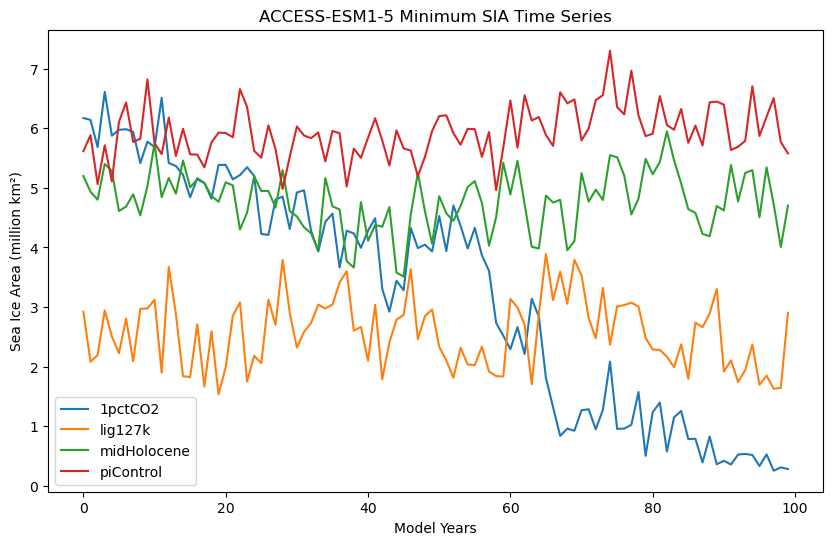

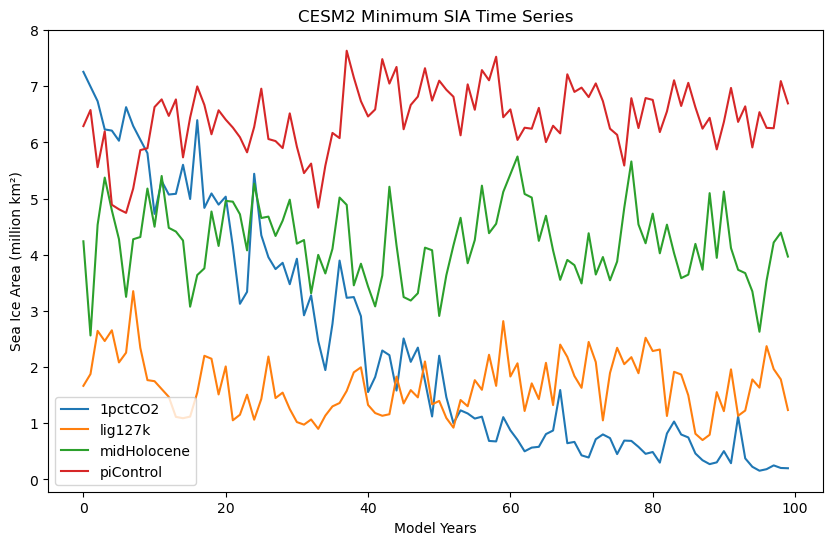

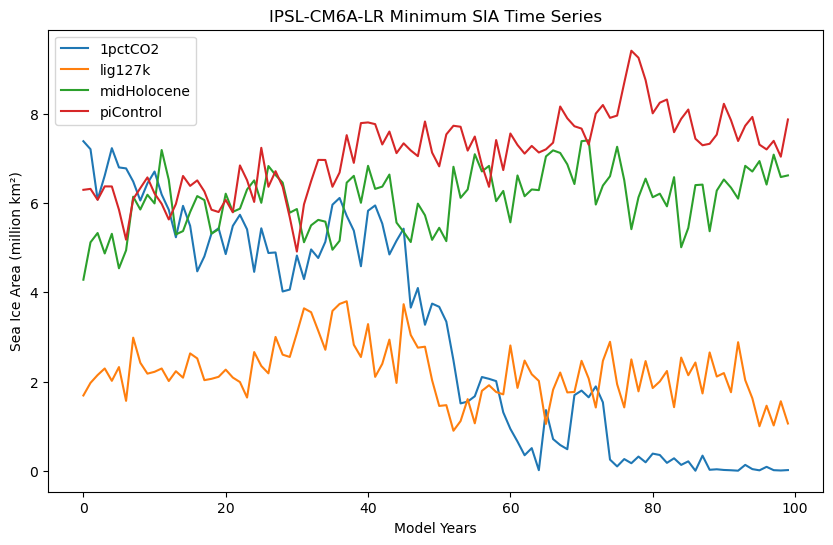

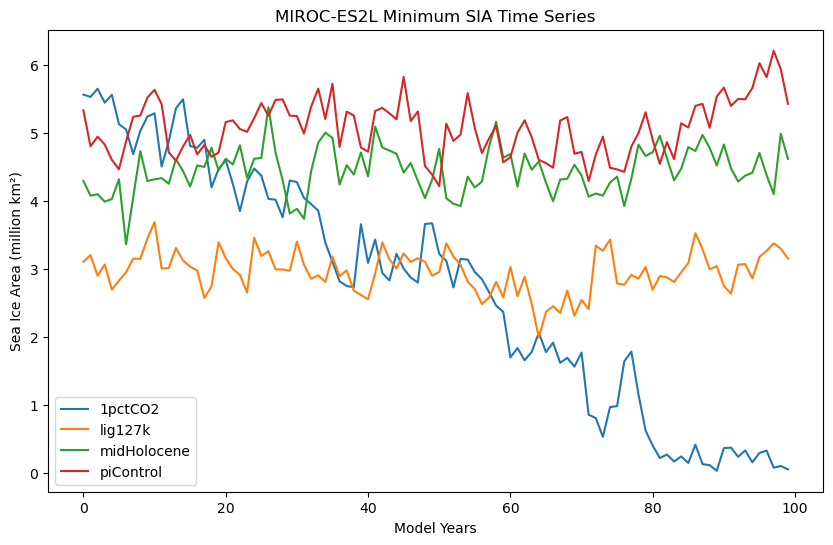

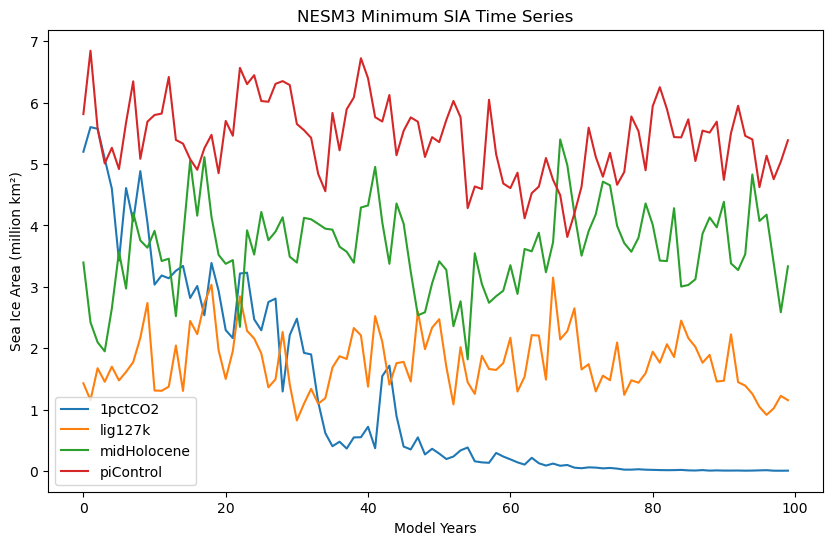

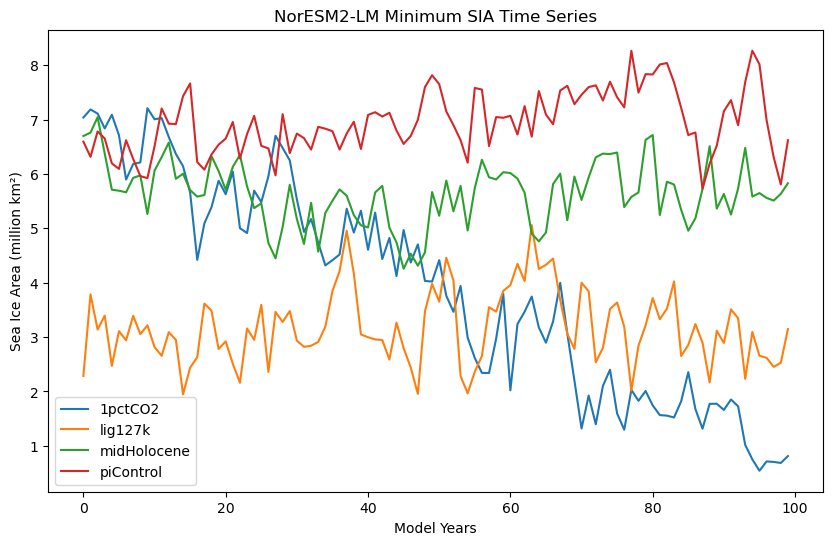

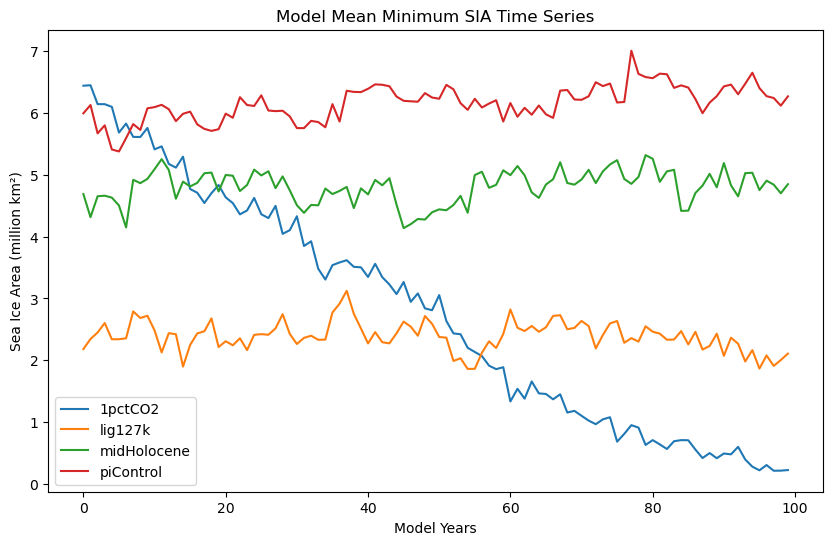

In [14]:
#better plots
transient_plot_mmm = None
paleo_plot_mmm = None
paleo2_plot_mmm = None
control_plot_mmm = None

for model in models:
    plt.figure(figsize=(10,6))
    plt.title(f'{model} Minimum SIA Time Series')
    transient_plot_data = transient_big_dict[model]['ts']['siconc'].extract(iris.Constraint(month=transient_month)).data[0:100]/1e14
    paleo_plot_data = paleo_big_dict[model]['ts']['siconc'].extract(iris.Constraint(month=paleo_month)).data[0:100]/1e14
    if paleo2:
        paleo2_plot_data = paleo2_big_dict[model]['ts']['siconc'].extract(iris.Constraint(month=paleo2_month)).data[0:100]/1e14
    control_plot_data = control_big_dict[model]['ts']['siconc'].extract(iris.Constraint(month=control_month)).data[0:100]/1e14
    if transient_plot_mmm is None:
        transient_plot_mmm = transient_plot_data
        paleo_plot_mmm = paleo_plot_data
        paleo2_plot_mmm = paleo2_plot_data
        control_plot_mmm = control_plot_data
    else:
        transient_plot_mmm += transient_plot_data
        paleo_plot_mmm += paleo_plot_data
        if paleo2:
            paleo2_plot_mmm += paleo2_plot_data
        control_plot_mmm += control_plot_data
    plt.plot(transient_plot_data, label=transient)
    plt.plot(paleo_plot_data, label=paleo)
    if paleo2:
        plt.plot(paleo2_plot_data, label=paleo2)
    plt.plot(control_plot_data, label=control)
    plt.xlabel('Model Years')
    plt.ylabel('Sea Ice Area (million km²)')
    plt.legend()
    plt.show()
transient_plot_mmm /= len(models)
paleo_plot_mmm /= len(models)
if paleo2:
    paleo2_plot_mmm /= len(models)
control_plot_mmm /= len(models)
plt.figure(figsize=(10,6))
plt.title(f'Model Mean Minimum SIA Time Series')
plt.plot(transient_plot_mmm, label=transient)
plt.plot(paleo_plot_mmm, label=paleo)
if paleo2:
    plt.plot(paleo2_plot_mmm, label=paleo2)
plt.plot(control_plot_mmm, label=control)
plt.xlabel('Model Years')
plt.ylabel('Sea Ice Area (million km²)')
plt.legend()
plt.show()

In [15]:
#for paleo, get sep siconc anomaly
def get_crossing_big_dict(models, paleo_big_dict, transient_big_dict, sia_crossing=None, window=10):
    

    crossing_big_dict = {}
    for model in models:
        
        if sia_crossing is None:
            paleo_siconc_anom = paleo_big_dict[model][ts_to_use]['siconc'].extract(iris.Constraint(month=paleo_month)).collapsed('year', iris.analysis.MEAN).data / 1e14
        else:
            paleo_siconc_anom = sia_crossing
            
        transient_siconc_ts_anom = transient_big_dict[model][ts_to_use]['siconc'].extract(iris.Constraint(month=transient_month)) / 1e14
        
        transient_min =  transient_siconc_ts_anom.data

        transient_min_rolling = pd.Series(transient_min).rolling(window=window, center=True).mean()

        n_years = transient_min_rolling.shape[0]
        years = np.arange(n_years) + 1

        crossing_mask = transient_min_rolling.to_numpy() <= paleo_siconc_anom

        if not np.any(crossing_mask):
            print(f"{model}: no crossing found")
            continue

        sia_crossing_idx = np.where(crossing_mask)[0][0]
        sia_crossing_year = years[sia_crossing_idx]
        #sia_crossing_year = years[transient_min_rolling <= paleo_siconc_anom][0]

        print(f'{model} paleo Aug siconc anomaly: {paleo_siconc_anom:.2f}, transient crossing year: {sia_crossing_year}')


        transient_siconc_ts_anom = (
        transient_big_dict[model][ts_to_use]['siconc']
        .extract(iris.Constraint(month=transient_month))
        / 1e14
        )

        transient_min = transient_siconc_ts_anom.data
        years_coord = transient_siconc_ts_anom.coord('year').points

        transient_min_rolling = (
            pd.Series(transient_min, index=years_coord)
            .rolling(window=window, center=True)
            .mean()
        )

        crossing_mask = transient_min_rolling.to_numpy() <= paleo_siconc_anom

        if not np.any(crossing_mask):
            print(f"{model}: no crossing found")
            continue

        crossing_year_value = transient_min_rolling.index[np.where(crossing_mask)[0][0]]
        
        crossing_cubes_dict = {}
        crossing_ts_dict = {}
        crossing_clim_dict = {}
        crossing_anom_ts_dict = {}
        crossing_anom_clim_dict = {}
        
        for var in var_list:

            # unique_years = transient_big_dict[model][ts_to_use]['siconc'].coord('year').points
            # crossing_year_value = unique_years[sia_crossing_year - 1]

            half_window = window // 2
            year_constraint = iris.Constraint(
                year=lambda y: crossing_year_value - half_window <= y < crossing_year_value + half_window
                )

            cube = transient_big_dict[model]['cubes'][var].extract(year_constraint)
            crossing_cubes_dict[var] = cube

            ts = transient_big_dict[model]['ts'][var].extract(year_constraint)
            crossing_ts_dict[var] = ts

            anom_ts = transient_big_dict[model]['anom_ts'][var].extract(year_constraint)
            crossing_anom_ts_dict[var] = anom_ts


        crossing_clim_dict = get_clim_dict_from_ts_dict(crossing_ts_dict)
        crossing_anom_clim_dict = get_clim_dict_from_ts_dict(crossing_anom_ts_dict)
        
        crossing_big_dict[model] = {'cubes': crossing_cubes_dict,
                                'ts': crossing_ts_dict,
                                'clim': crossing_clim_dict,
                                'anom_ts': crossing_anom_ts_dict,
                                'anom_clim': crossing_anom_clim_dict,
                                }
    return crossing_big_dict


In [16]:
crossing_big_dict = get_crossing_big_dict(models, paleo_big_dict, transient_big_dict, sia_crossing=sia_crossing, window=10)


ACCESS-ESM1-5 paleo Aug siconc anomaly: -3.70, transient crossing year: 65
Calculating climatology for...siconc...rsds...rlds...Done.
Calculating climatology for...siconc...rsds...rlds...Done.
CESM2 paleo Aug siconc anomaly: -4.96, transient crossing year: 57
Calculating climatology for...siconc...rsds...rlds...Done.
Calculating climatology for...siconc...rsds...rlds...Done.
IPSL-CM6A-LR paleo Aug siconc anomaly: -4.15, transient crossing year: 52
Calculating climatology for...siconc...rsds...rlds...Done.
Calculating climatology for...siconc...rsds...rlds...Done.
MIROC-ES2L paleo Aug siconc anomaly: -1.57, transient crossing year: 34
Calculating climatology for...siconc...rsds...rlds...Done.
Calculating climatology for...siconc...rsds...rlds...Done.
NESM3 paleo Aug siconc anomaly: -4.14, transient crossing year: 34
Calculating climatology for...siconc...rsds...rlds...Done.
Calculating climatology for...siconc...rsds...rlds...Done.
NorESM2-LM paleo Aug siconc anomaly: -4.06, transient c

In [17]:
crossing2_big_dict = get_crossing_big_dict(models, paleo2_big_dict, transient_big_dict, sia_crossing=sia_crossing, window=10)
  


ACCESS-ESM1-5 paleo Aug siconc anomaly: -0.81, transient crossing year: 23
Calculating climatology for...siconc...rsds...rlds...Done.
Calculating climatology for...siconc...rsds...rlds...Done.
CESM2 paleo Aug siconc anomaly: -1.65, transient crossing year: 23
Calculating climatology for...siconc...rsds...rlds...Done.
Calculating climatology for...siconc...rsds...rlds...Done.
IPSL-CM6A-LR paleo Aug siconc anomaly: -0.72, transient crossing year: 11
Calculating climatology for...siconc...rsds...rlds...Done.
Calculating climatology for...siconc...rsds...rlds...Done.
MIROC-ES2L paleo Aug siconc anomaly: -0.60, transient crossing year: 20
Calculating climatology for...siconc...rsds...rlds...Done.
Calculating climatology for...siconc...rsds...rlds...Done.
NESM3 paleo Aug siconc anomaly: -1.70, transient crossing year: 10
Calculating climatology for...siconc...rsds...rlds...Done.
Calculating climatology for...siconc...rsds...rlds...Done.
NorESM2-LM paleo Aug siconc anomaly: -1.03, transient c

In [18]:
# #look at info for the clear sky radiation
# model = 'ACCESS-ESM1-5'

# rsds_control_cube = control_big_dict[model]['cubes']['rsds']
# rsdscs_control_cube = control_big_dict[model]['cubes']['rsdscs']
# rlds_control_cube = control_big_dict[model]['cubes']['rlds']
# rldscs_control_cube = control_big_dict[model]['cubes']['rldscs']

# rsds_paleo_cube = paleo_big_dict[model]['cubes']['rsds']
# rsdscs_paleo_cube = paleo_big_dict[model]['cubes']['rsdscs']
# rlds_paleo_cube = paleo_big_dict[model]['cubes']['rlds']
# rldscs_paleo_cube = paleo_big_dict[model]['cubes']['rldscs']

# rsds_paleo2_cube = paleo2_big_dict[model]['cubes']['rsds']
# rsdscs_paleo2_cube = paleo2_big_dict[model]['cubes']['rsdscs']
# rlds_paleo2_cube = paleo2_big_dict[model]['cubes']['rlds']
# rldscs_paleo2_cube = paleo2_big_dict[model]['cubes']['rldscs']

# rsds_crossing_cube = crossing_big_dict[model]['cubes']['rsds']
# rsdscs_crossing_cube = crossing_big_dict[model]['cubes']['rsdscs']
# rlds_crossing_cube = crossing_big_dict[model]['cubes']['rlds']
# rldscs_crossing_cube = crossing_big_dict[model]['cubes']['rldscs']

# rsds_crossing2_cube = crossing2_big_dict[model]['cubes']['rsds']
# rsdscs_crossing2_cube = crossing2_big_dict[model]['cubes']['rsdscs']
# rlds_crossing2_cube = crossing2_big_dict[model]['cubes']['rlds']
# rldscs_crossing2_cube = crossing2_big_dict[model]['cubes']['rldscs']



In [19]:

# def get_scloud_clim(energy_cube, clearsky_cube):
#     scloud_cube = energy_cube - clearsky_cube
#     area_weights = iris.analysis.cartography.area_weights(scloud_cube)
#     op = get_iris_op('mean')
#     scloud_timeseries = (scloud_cube.collapsed(['latitude', 'longitude'], op, weights=area_weights))
#     scloud_clim = scloud_timeseries.aggregated_by('month', op)
#     return scloud_clim


In [20]:


# scloud_control_clim = get_scloud_clim(rsds_control_cube, rsdscs_control_cube)
# scloud_paleo_clim = get_scloud_clim(rsds_paleo_cube, rsdscs_paleo_cube)
# scloud_paleo2_clim = get_scloud_clim(rsds_paleo2_cube, rsdscs_paleo2_cube)
# scloud_crossing_clim = get_scloud_clim(rsds_crossing_cube, rsdscs_crossing_cube)
# scloud_crossing2_clim = get_scloud_clim(rsds_crossing2_cube, rsdscs_crossing2_cube) 


In [21]:

# lcloud_control_clim = get_scloud_clim(rlds_control_cube, rldscs_control_cube)
# lcloud_paleo_clim = get_scloud_clim(rlds_paleo_cube, rldscs_paleo_cube)
# lcloud_paleo2_clim = get_scloud_clim(rlds_paleo2_cube, rldscs_paleo2_cube)
# lcloud_crossing_clim = get_scloud_clim(rlds_crossing_cube, rldscs_crossing_cube)
# lcloud_crossing2_clim = get_scloud_clim(rlds_crossing2_cube, rldscs_crossing2_cube)



In [22]:
# plt.plot(scloud_paleo_clim.data - scloud_control_clim.data, label=f'{paleo}')
# plt.plot(scloud_paleo2_clim.data - scloud_control_clim.data, label=f'{paleo2}')
# plt.plot(scloud_crossing_clim.data - scloud_control_clim.data, label=f'{paleo} Crossing Point')
# plt.plot(scloud_crossing2_clim.data - scloud_control_clim.data, label=f'{paleo2} Crossing Point')
# #month labels
# plt.xticks(np.arange(12), months)
# plt.xlabel('Month')
# plt.ylabel('Shortwave Cloud Effect Anomaly (W/m²)')
# plt.grid()
# plt.legend()
# plt.show()

In [23]:
# #plt.plot(lcloud_control_clim.data, label='Control LW')
# plt.plot(lcloud_paleo_clim.data - lcloud_control_clim.data, label=f'{paleo}')
# plt.plot(lcloud_paleo2_clim.data - lcloud_control_clim.data, label=f'{paleo2}')
# plt.plot(lcloud_crossing_clim.data - lcloud_control_clim.data, label=f'{paleo} Crossing Point')
# plt.plot(lcloud_crossing2_clim.data - lcloud_control_clim.data, label=f'{paleo2} Crossing Point')
# plt.xticks(np.arange(12), months)
# plt.xlabel('Month')
# plt.ylabel('Shortwave Cloud Effect Anomaly (W/m²)')
# plt.grid()
# plt.legend()
# plt.show()

In [24]:
# plt.plot(lcloud_paleo_clim.data - lcloud_control_clim.data + scloud_paleo_clim.data - scloud_control_clim.data, label=f'{paleo}')
# plt.plot(lcloud_paleo2_clim.data - lcloud_control_clim.data + scloud_paleo2_clim.data - scloud_control_clim.data, label=f'{paleo2}')
# plt.plot(lcloud_crossing_clim.data - lcloud_control_clim.data + scloud_crossing_clim.data - scloud_control_clim.data, label=f'{paleo} Crossing Point')
# plt.plot(lcloud_crossing2_clim.data - lcloud_control_clim.data + scloud_crossing2_clim.data - scloud_control_clim.data, label=f'{paleo2} Crossing Point')
# plt.xticks(np.arange(12), months)
# plt.xlabel('Month')
# plt.ylabel('Total Cloud Effect Anomaly (W/m²)')
# plt.grid()
# plt.legend()
# plt.show()

In [25]:
def plot_arctic_maps(models, big_dict, plot_month='Sep', vmin=0.0, vmax=100, gamma=1.0, cmap='viridis', 
                     cbar_label='Sea Ice Concentration (%)', plot_title='', nrows=2, extract = True, plot_mmm = True):
    
    ncols = int(np.ceil((len(models) + int(plot_mmm)) / nrows))


    color_norm = colors.PowerNorm(gamma=gamma, vmin=vmin, vmax=vmax)
    
    cbar_label = 'Sea Ice Concentration (%)'

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(3.5 * ncols, 10),
        subplot_kw={'projection': ccrs.NorthPolarStereo()}
    )
    axes = np.atleast_1d(axes).flatten()

    theta = np.linspace(0, 2*np.pi, 100)
    x = 0.5 + 0.5*np.cos(theta)
    y = 0.5 + 0.5*np.sin(theta)
    circle_path = mpath.Path(np.column_stack([x, y]))

    # Build all monthly-mean cubes first
    plot_cubes = []
    for model in models:
        if extract:
            cube = (
                big_dict[model]['cubes']['siconc']
                .extract(iris.Constraint(month=plot_month))
                .collapsed('year', iris.analysis.MEAN)
            )
        else:
            cube = big_dict[model]['cubes']['siconc']
            
        plot_cubes.append(cube)
        #print(model, cube.shape)

    # Use first model as reference grid
    ref_cube = plot_cubes[0]

    # Plot individual models
    regridded_data = []

    for i, (model, plot_data) in enumerate(zip(models, plot_cubes)):
        ax = axes[i]

        ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
        ax.set_boundary(circle_path, transform=ax.transAxes)
        ax.coastlines()
        ax.gridlines()
        ax.add_feature(cfeature.LAND, color='#a9a9a9', zorder=4)

        qplt.contourf(plot_data, axes=ax, cmap=cmap, norm=color_norm)
        ax.set_title(model, fontsize=10)

        # Regrid to common grid for MMM
        if i == 0:
            regridded_cube = plot_data.copy()
        else:
            regridded_cube = plot_data.regrid(ref_cube, iris.analysis.Linear())

        regridded_data.append(regridded_cube.data)

    # MMM

    mmm_cube = ref_cube.copy()
    mmm_cube.data = np.mean(np.stack(regridded_data, axis=0), axis=0)
    if plot_mmm:
        ax = axes[-1]
        ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
        ax.set_boundary(circle_path, transform=ax.transAxes)
        ax.coastlines()
        ax.gridlines()
        ax.add_feature(cfeature.LAND, color='#a9a9a9', zorder=4)

        qplt.contourf(mmm_cube, axes=ax, cmap=cmap, norm=color_norm)
        ax.set_title("MMM", fontsize=10)

    for a in fig.axes.copy():
        if not hasattr(a, 'projection'):
            fig.delaxes(a)
    plt.suptitle(plot_title, fontsize=12)
    plt.tight_layout(rect=[0, 0.1, 1, 1])

    sm = cm.ScalarMappable(norm=color_norm, cmap=cmap)
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes,
        orientation='horizontal',
        fraction=0.05,
        pad=0.05
    )
    cbar.set_label(cbar_label)
    

    plt.show()

    return mmm_cube

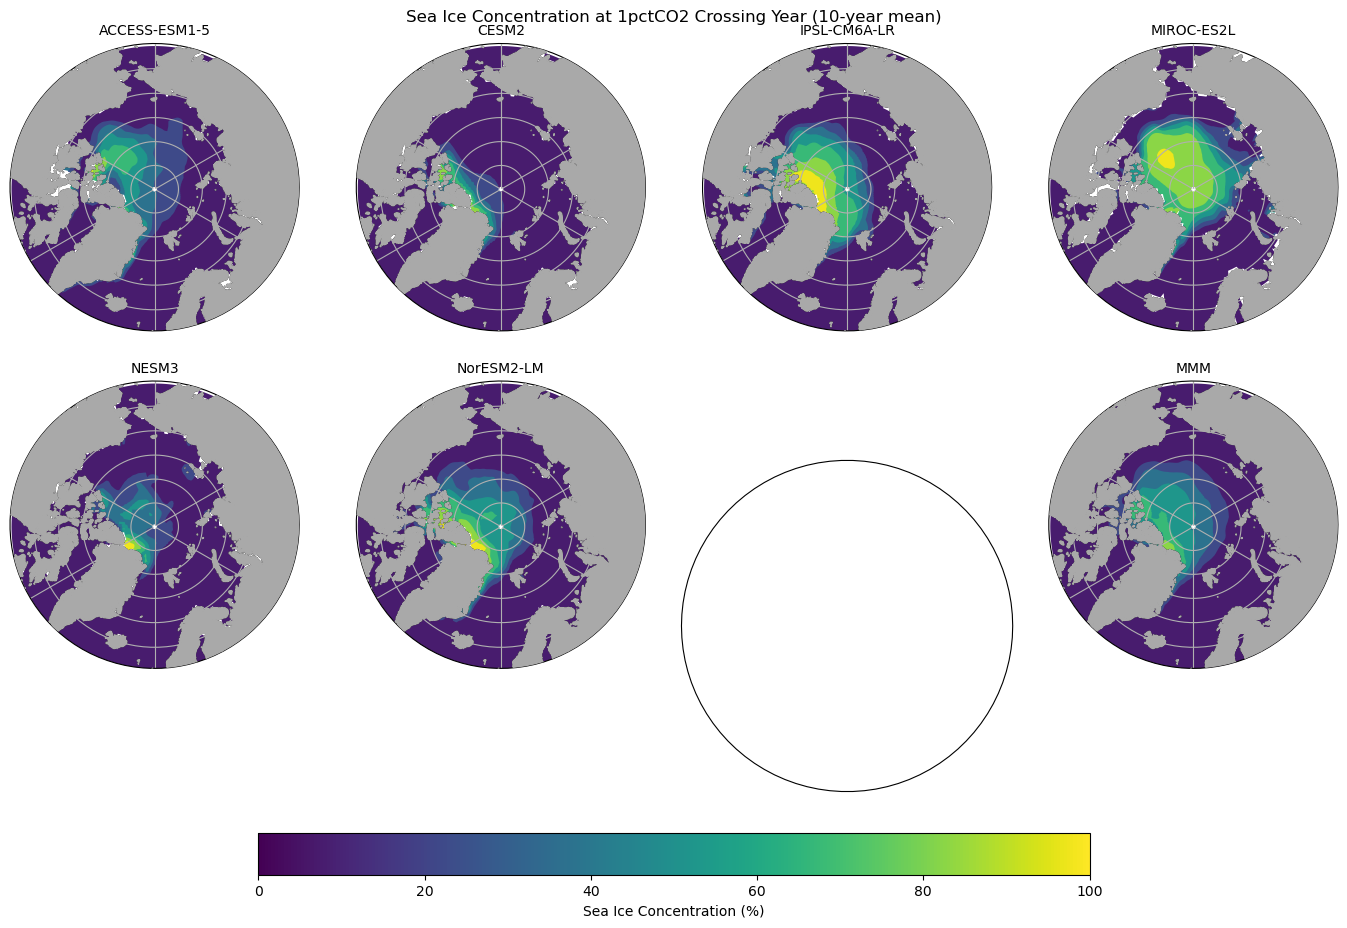

In [26]:
crossing_mmm_cube = plot_arctic_maps(models, crossing_big_dict, plot_month=transient_month, plot_title=f'Sea Ice Concentration at {transient} Crossing Year (10-year mean)')

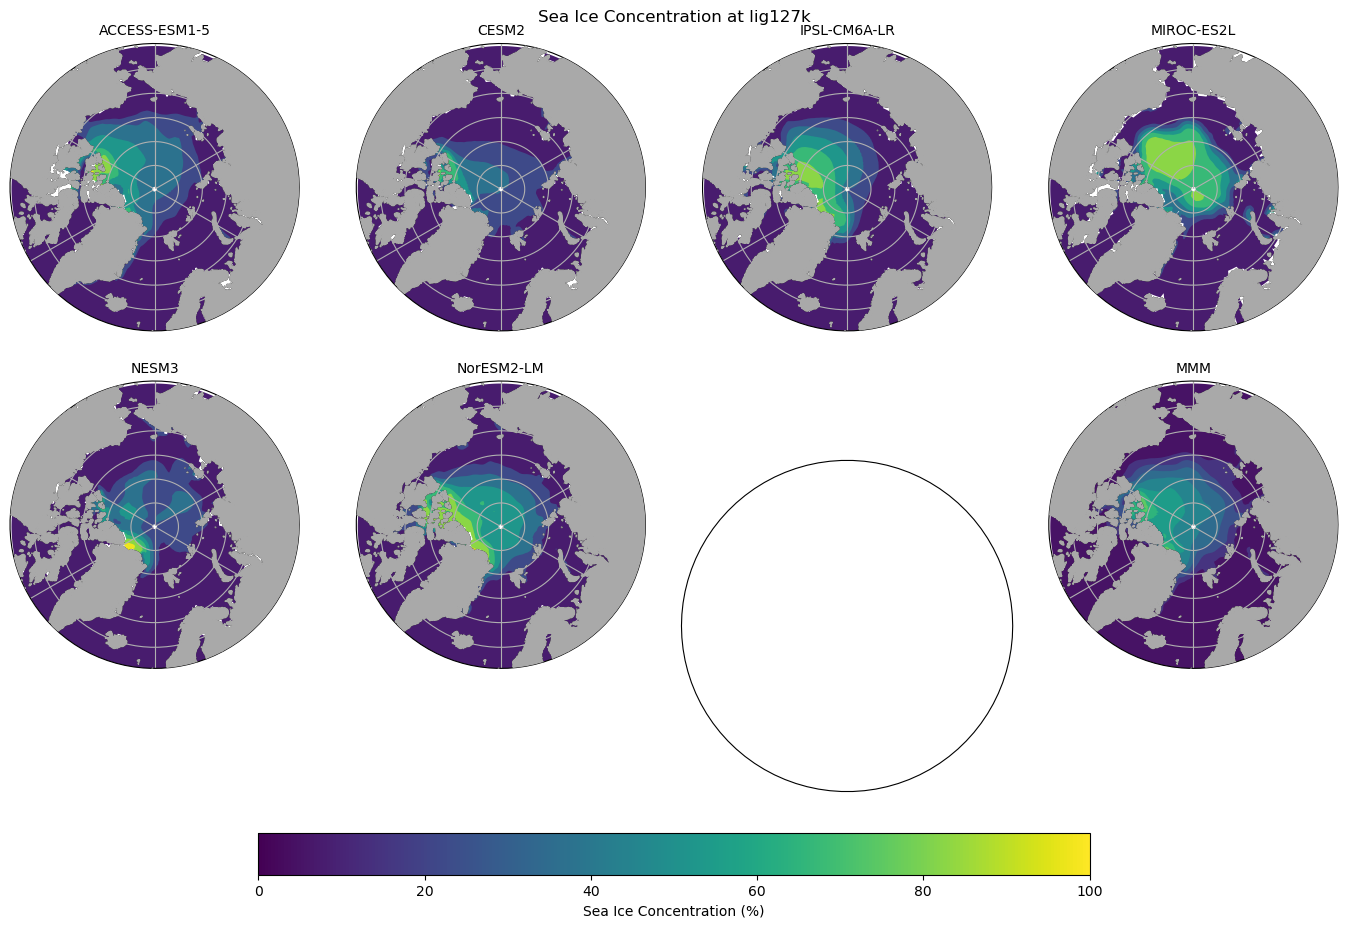

In [27]:
paleo_mmm_cube = plot_arctic_maps(models, paleo_big_dict, plot_month=paleo_month, plot_title=f'Sea Ice Concentration at {paleo}')

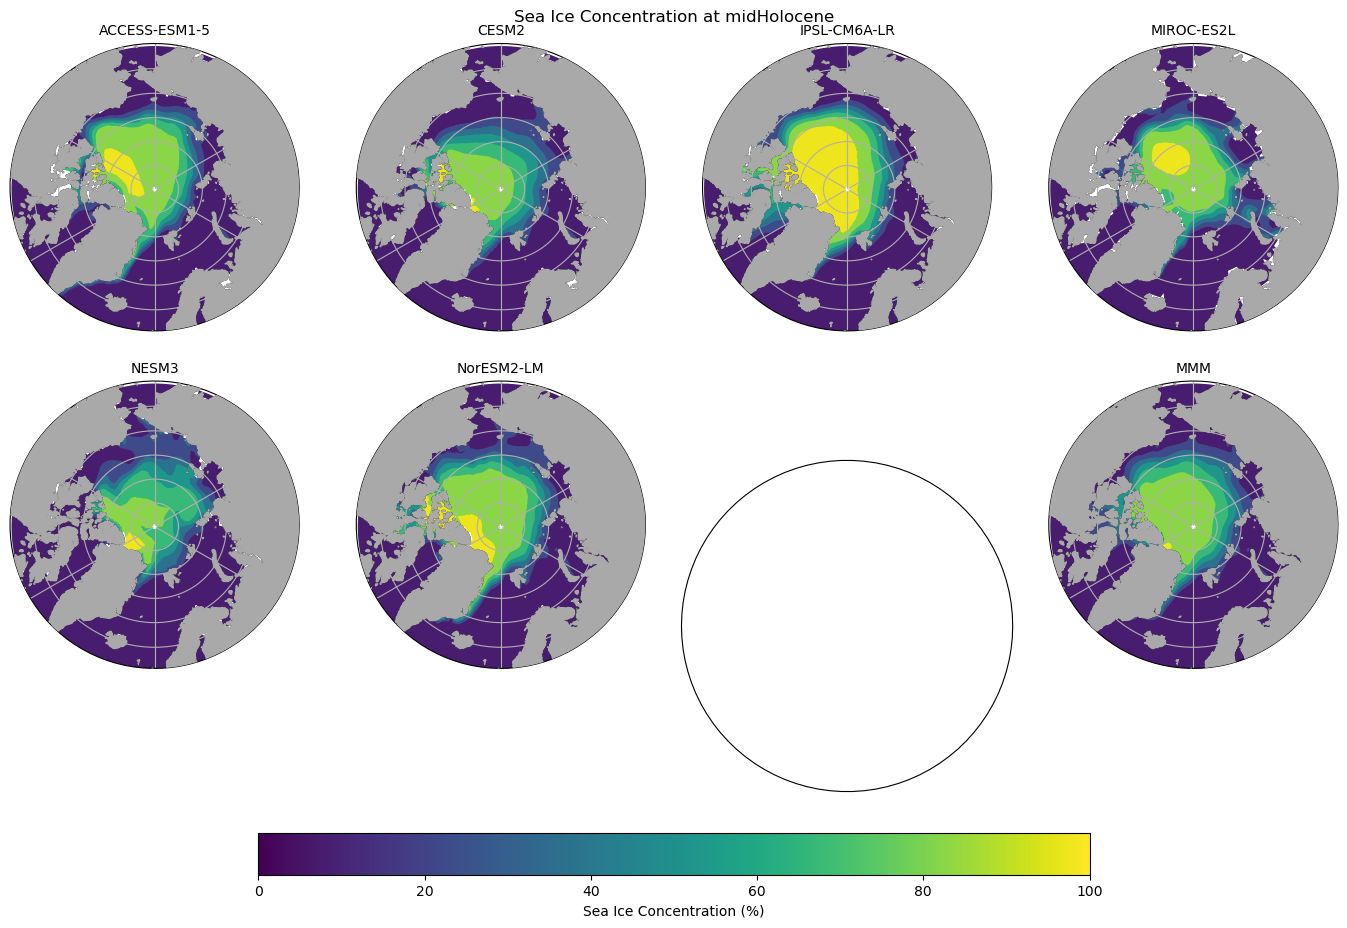

In [28]:
paleo2_mmm_cube = plot_arctic_maps(models, paleo2_big_dict, plot_month=paleo2_month, plot_title=f'Sea Ice Concentration at {paleo2}')

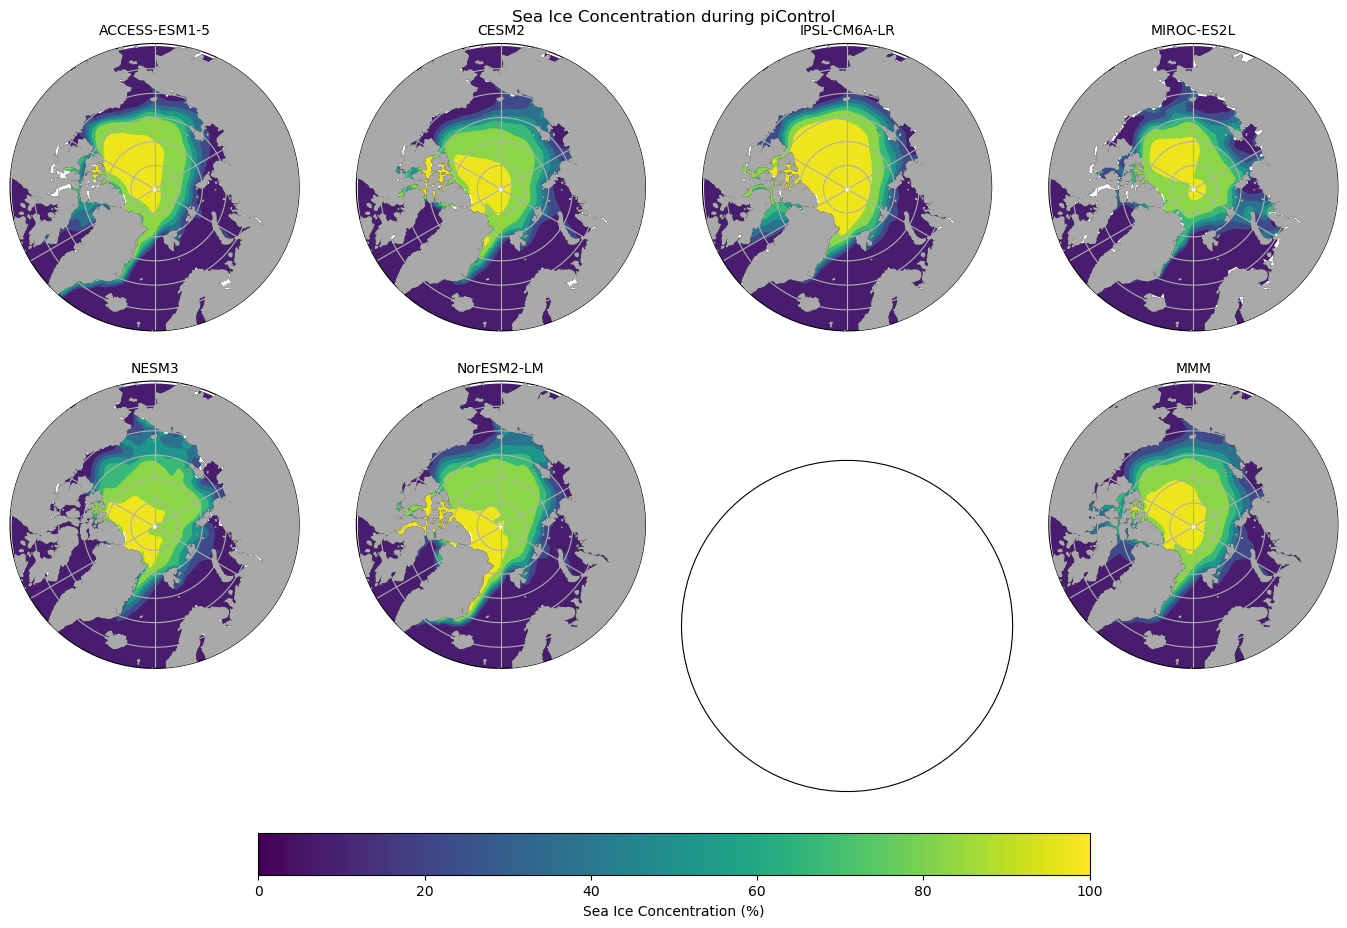

In [29]:
control_mmm_cube = plot_arctic_maps(models, control_big_dict, plot_month=control_month, plot_title=f'Sea Ice Concentration during piControl')

In [30]:

crossing_minus_paleo_cube = crossing_mmm_cube - paleo_mmm_cube

control_minus_paleo_cube = control_mmm_cube - paleo_mmm_cube

control_minus_crossing_cube = control_mmm_cube - crossing_mmm_cube

In [31]:
mmm_big_dict = {}
mmm_big_dict['Cross-Paleo'] = {}
mmm_big_dict['Cross-Paleo']['cubes'] = {}
mmm_big_dict['Cross-Paleo']['cubes']['siconc'] = crossing_minus_paleo_cube
mmm_big_dict['Control-Cross'] = {}
mmm_big_dict['Control-Cross']['cubes'] = {}
mmm_big_dict['Control-Cross']['cubes']['siconc'] = control_minus_crossing_cube
mmm_big_dict['Control-Paleo'] = {}
mmm_big_dict['Control-Paleo']['cubes'] = {}
mmm_big_dict['Control-Paleo']['cubes']['siconc'] = control_minus_paleo_cube


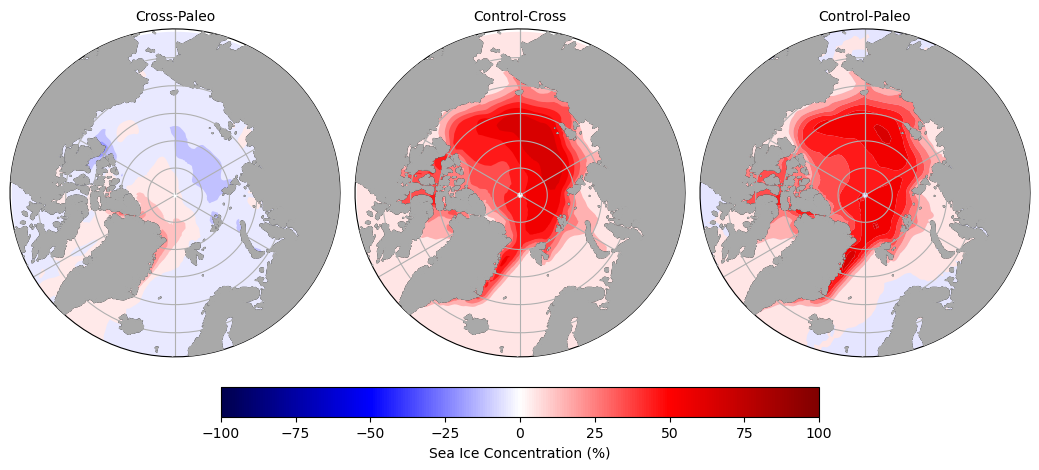

In [32]:
_ = plot_arctic_maps(list(mmm_big_dict.keys()), mmm_big_dict, extract=False, vmax = 100, vmin = -100, cmap='seismic', nrows=1, plot_mmm=False)

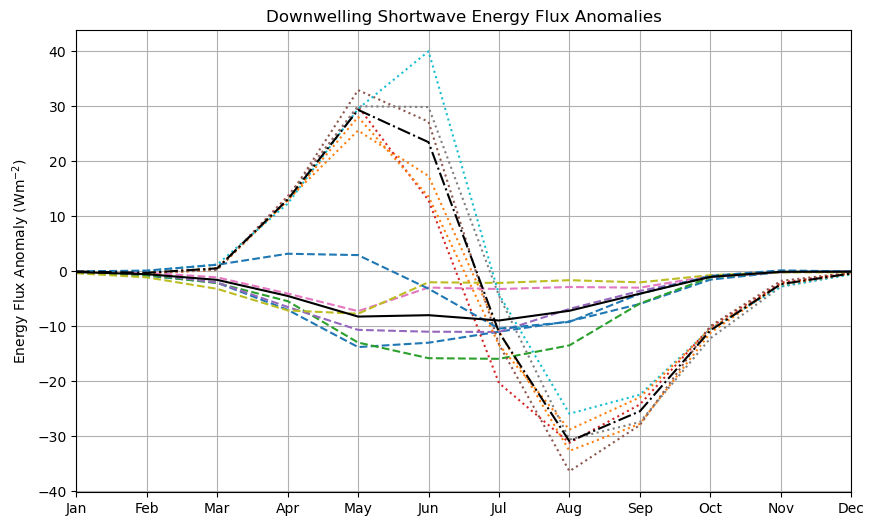

In [33]:
rsds_mmm_crossing = np.zeros(12)
rsds_mmm_paleo = np.zeros(12)

plt.figure(figsize=(10,6))
for model in models:
    crossing_energy = crossing_big_dict[model]['anom_clim']['rsds'].data
    plt.plot(crossing_energy, label=model, linestyle='--')
    #plt.plot(crossing_big_dict[model]['rlds'].data)
    paleo_energy = paleo_big_dict[model]['anom_clim']['rsds'].data 
    plt.plot(paleo_energy, linestyle=':')
    #plt.plot(paleo_big_dict[model]['anom_clim']['rlds'].data)
    rsds_mmm_crossing += crossing_energy
    rsds_mmm_paleo += paleo_energy
rsds_mmm_crossing /= len(models)
rsds_mmm_paleo /= len(models)
plt.plot(rsds_mmm_crossing, label='Crossing Year MMM', color='black', linestyle='-')
plt.plot(rsds_mmm_paleo, label='Paleo MMM', color='black', linestyle='-.')

plt.grid(True)
plt.xlim(0, 11)
plt.xticks(np.arange(12), months)
plt.ylabel('Energy Flux Anomaly (Wm$^{-2}$)')
plt.title(f'Downwelling Shortwave Energy Flux Anomalies')
#plt.legend()
plt.show()

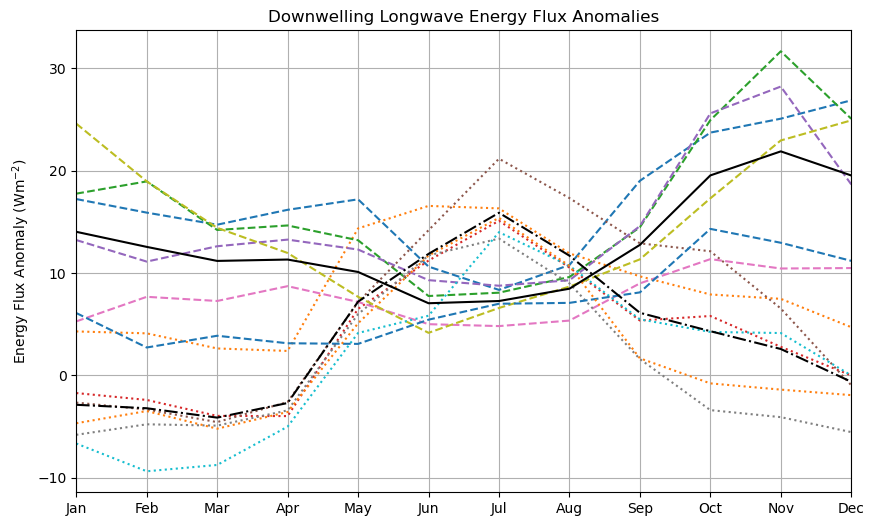

In [34]:
rlds_mmm_crossing = np.zeros(12)
rlds_mmm_paleo = np.zeros(12)

plt.figure(figsize=(10,6))
for model in models:
    crossing_energy = crossing_big_dict[model]['anom_clim']['rlds'].data
    plt.plot(crossing_energy, label=model, linestyle='--')
    #plt.plot(crossing_big_dict[model]['rlds'].data)
    paleo_energy = paleo_big_dict[model]['anom_clim']['rlds'].data
    plt.plot(paleo_energy, linestyle=':')
    #plt.plot(paleo_big_dict[model]['anom_clim']['rlds'].data)
    rlds_mmm_crossing += crossing_energy
    rlds_mmm_paleo += paleo_energy
rlds_mmm_crossing /= len(models)
rlds_mmm_paleo /= len(models)
plt.plot(rlds_mmm_crossing, label='Crossing Year MMM', color='black', linestyle='-')
plt.plot(rlds_mmm_paleo, label='Paleo MMM', color='black', linestyle='-.')

plt.grid(True)
plt.xlim(0, 11)
plt.xticks(np.arange(12), months)
plt.ylabel('Energy Flux Anomaly (Wm$^{-2}$)')
plt.title(f'Downwelling Longwave Energy Flux Anomalies')
#plt.legend()
plt.show()

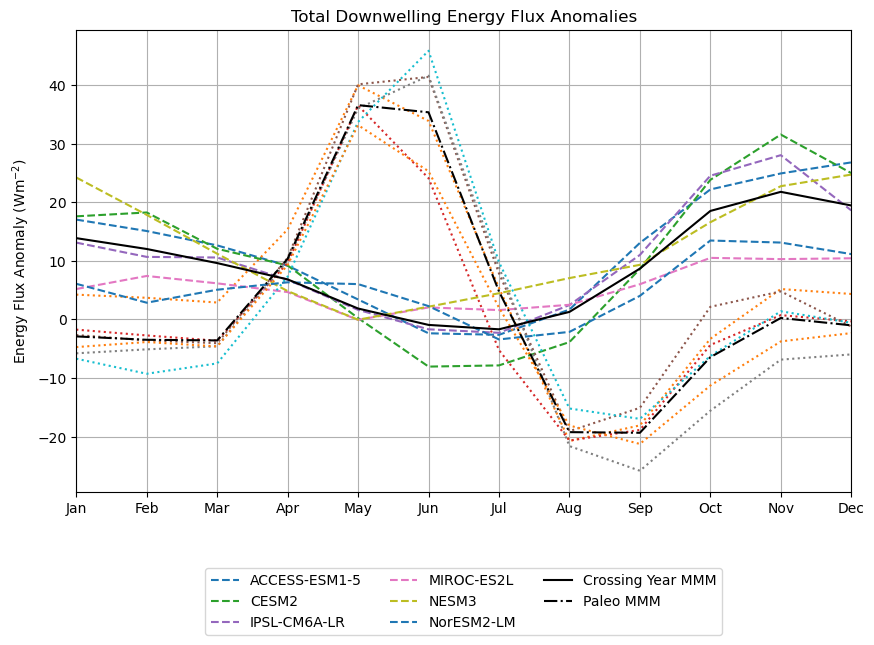

In [35]:

total_mmm_crossing = np.zeros(12)
total_mmm_paleo = np.zeros(12)

plt.figure(figsize=(10,6))
for model in models:
    crossing_energy = crossing_big_dict[model]['anom_clim']['rsds'].data + crossing_big_dict[model]['anom_clim']['rlds'].data
    plt.plot(crossing_energy, label=model, linestyle='--')
    #plt.plot(crossing_big_dict[model]['rlds'].data)
    paleo_energy = paleo_big_dict[model]['anom_clim']['rsds'].data + paleo_big_dict[model]['anom_clim']['rlds'].data
    plt.plot(paleo_energy, linestyle=':')
    #plt.plot(paleo_big_dict[model]['anom_clim']['rlds'].data)
    total_mmm_crossing += crossing_energy
    total_mmm_paleo += paleo_energy
total_mmm_crossing /= len(models)
total_mmm_paleo /= len(models)
plt.plot(total_mmm_crossing, label='Crossing Year MMM', color='black', linestyle='-')
plt.plot(total_mmm_paleo, label='Paleo MMM', color='black', linestyle='-.')
plt.grid(True)
plt.xlim(0, 11)
plt.xticks(np.arange(12), months)
plt.ylabel('Energy Flux Anomaly (Wm$^{-2}$)')
plt.title(f'Total Downwelling Energy Flux Anomalies')
#place legend outside of plot at the bottom
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.show()

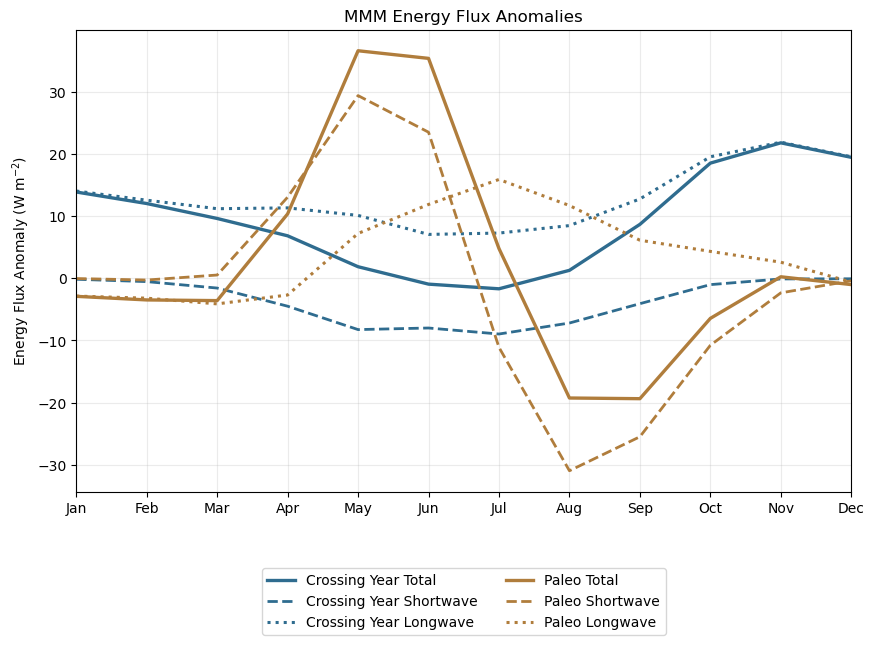

In [36]:
plt.figure(figsize=(10,6))

# Muted, publication-friendly palette
future_col = '#2F6C8F'   # muted blue-teal
paleo_col  = '#B07D3C'   # muted warm brown

# Future / crossing year
plt.plot(total_mmm_crossing, label='Crossing Year Total',
         color=future_col, linestyle='-', linewidth=2.4)

plt.plot(rsds_mmm_crossing, label='Crossing Year Shortwave',
         color=future_col, linestyle='--', linewidth=2.0)

plt.plot(rlds_mmm_crossing, label='Crossing Year Longwave',
         color=future_col, linestyle=':', linewidth=2.2)

# Paleo
plt.plot(total_mmm_paleo, label='Paleo Total',
         color=paleo_col, linestyle='-', linewidth=2.4)

plt.plot(rsds_mmm_paleo, label='Paleo Shortwave',
         color=paleo_col, linestyle='--', linewidth=2.0)

plt.plot(rlds_mmm_paleo, label='Paleo Longwave',
         color=paleo_col, linestyle=':', linewidth=2.2)

# Formatting
plt.grid(True, alpha=0.25, linewidth=0.8)
plt.xlim(0, 11)
plt.xticks(np.arange(12), months)
plt.ylabel('Energy Flux Anomaly (W m$^{-2}$)')
plt.title('MMM Energy Flux Anomalies')

# Cleaner legend
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

#plt.tight_layout()
plt.show()

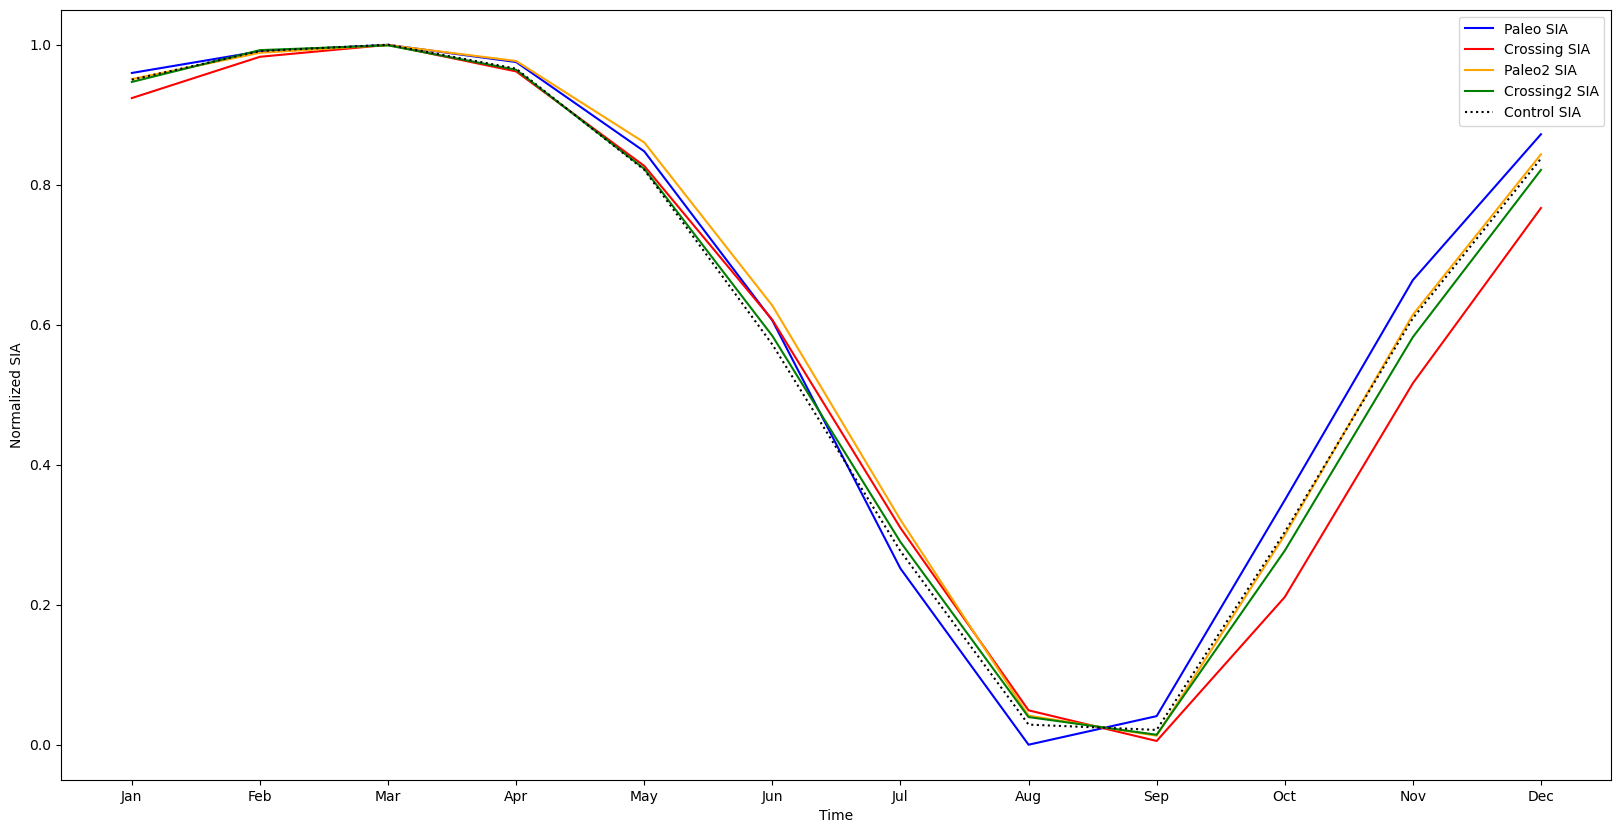

In [37]:
#plot sia climatologies, as percentages of max / min value
plt.figure(figsize=(20, 10))
paleo_sia_clim_mmm = None
crossing_sia_clim_mmm = None
paleo2_sia_clim_mmm = None
crossing2_sia_clim_mmm = None
control_sia_clim_mmm = None

for model in models:
    
    paleo_sia_clim = paleo_big_dict[model]['clim']['siconc'].data / 1e14
    crossing_sia_clim = crossing_big_dict[model]['clim']['siconc'].data / 1e14

    paleo2_sia_clim = paleo2_big_dict[model]['clim']['siconc'].data / 1e14
    crossing2_sia_clim = crossing2_big_dict[model]['clim']['siconc'].data / 1e14

    control_sia_clim = control_big_dict[model]['clim']['siconc'].data / 1e14

    # Calculate max/min values for normalization
    paleo_sia_clim_max = paleo_sia_clim.max()
    paleo_sia_clim_min = paleo_sia_clim.min()
    crossing_sia_clim_max = crossing_sia_clim.max()
    crossing_sia_clim_min = crossing_sia_clim.min()

    paleo2_sia_clim_max = paleo2_sia_clim.max()
    paleo2_sia_clim_min = paleo2_sia_clim.min()
    crossing2_sia_clim_max = crossing2_sia_clim.max()
    crossing2_sia_clim_min = crossing2_sia_clim.min()

    control_sia_clim_max = control_sia_clim.max()
    control_sia_clim_min = control_sia_clim.min()

    # Normalize climatologies
    paleo_sia_clim_norm = (paleo_sia_clim - paleo_sia_clim_min) / (paleo_sia_clim_max - paleo_sia_clim_min)
    crossing_sia_clim_norm = (crossing_sia_clim - crossing_sia_clim_min) / (crossing_sia_clim_max - crossing_sia_clim_min)

    paleo2_sia_clim_norm = (paleo2_sia_clim - paleo2_sia_clim_min) / (paleo2_sia_clim_max - paleo2_sia_clim_min)
    crossing2_sia_clim_norm = (crossing2_sia_clim - crossing2_sia_clim_min) / (crossing2_sia_clim_max - crossing2_sia_clim_min)

    control_sia_clim_norm = (control_sia_clim - control_sia_clim_min) / (control_sia_clim_max - control_sia_clim_min)

    if paleo_sia_clim_mmm is None:
        paleo_sia_clim_mmm = paleo_sia_clim_norm
        crossing_sia_clim_mmm = crossing_sia_clim_norm
        paleo2_sia_clim_mmm = paleo2_sia_clim_norm
        crossing2_sia_clim_mmm = crossing2_sia_clim_norm
        control_sia_clim_mmm = control_sia_clim_norm
    else:
        paleo_sia_clim_mmm += paleo_sia_clim_norm
        crossing_sia_clim_mmm += crossing_sia_clim_norm
        paleo2_sia_clim_mmm += paleo2_sia_clim_norm
        crossing2_sia_clim_mmm += crossing2_sia_clim_norm
        control_sia_clim_mmm += control_sia_clim_norm

    # Plotting

paleo_sia_clim_mmm /= len(models)
crossing_sia_clim_mmm /= len(models)
paleo2_sia_clim_mmm /= len(models)
crossing2_sia_clim_mmm /= len(models)
control_sia_clim_mmm /= len(models)
plt.plot(paleo_sia_clim_mmm, label=f'Paleo SIA', color='blue')
plt.plot(crossing_sia_clim_mmm, label=f'Crossing SIA', color='red')

plt.plot(paleo2_sia_clim_mmm, label=f'Paleo2 SIA', color='orange')
plt.plot(crossing2_sia_clim_mmm, label=f'Crossing2 SIA', color='green')

plt.plot(control_sia_clim_mmm, label=f'Control SIA', color='black', linestyle=':')

#add month labels to x axis
plt.xticks(np.arange(12), months)

#show only months from Apr to Dec
#plt.xlim(2, 11)

plt.xlabel('Time')
plt.ylabel('Normalized SIA')
plt.legend()
plt.show()

In [38]:

def skewed_gaussian_month_weights(mu, sigma, skew, kurt = 2, x = np.arange(1, 13)):
    """
    Circular Gaussian month weights with a smooth circular skew term.

    Parameters
    ----------
    mu : float
        Peak month (1..12)
    sigma : float
        Width (>0)
    skew : float
        Asymmetry parameter.
        0 = symmetric
        >0 biases weights toward later months
        <0 biases weights toward earlier months
    """
    if sigma <= 0:
        return None

    effective_skew = skew / (1 + sigma / 6) #damp skew for wider distributions to avoid extreme weights

    # signed circular month difference in [-6, 6)
    d = (x - mu + 6) % 12 - 6

    # symmetric circular Gaussian envelope
    g = np.exp(-0.5 * abs(d / sigma) ** kurt)

    # smooth skew term using angle around the circle
    theta = 2 * np.pi * d / 12.0
    s = np.exp(effective_skew * np.sin(theta))

    w = g * s
    w = w / w.sum()
    return w

def weighted_linear_regression(x, y, weights=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if weights is None:
        A = np.column_stack([x, np.ones_like(x)])
        slope, intercept = np.linalg.lstsq(A, y, rcond=None)[0]
        return slope, intercept

    weights = np.asarray(weights, dtype=float)

    if weights.shape != x.shape:
        raise ValueError("weights must match x/y shape")
    if np.any(weights < 0):
        raise ValueError("weights must be non-negative")
    if np.sum(weights) == 0:
        raise ValueError("weights must not all be zero")

    # Weighted least squares via sqrt(weights)
    sw = np.sqrt(weights)
    A = np.column_stack([x, np.ones_like(x)])
    Aw = A * sw[:, None]
    yw = y * sw

    slope, intercept = np.linalg.lstsq(Aw, yw, rcond=None)[0]
    return slope, intercept

def weighted_rmse(y_true, y_pred, weights=None):
    """
    Compute weighted RMSE.

    Parameters
    ----------
    y_true, y_pred : array-like
        Values to compare.
    weights : array-like or None
        Non-negative weights for each sample/model.

    Returns
    -------
    float
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if weights is None:
        return np.sqrt(np.mean((y_true - y_pred) ** 2))

    weights = np.asarray(weights, dtype=float)

    if weights.shape != y_true.shape:
        raise ValueError(
            f"weights shape {weights.shape} does not match data shape {y_true.shape}"
        )
    if np.any(weights < 0):
        raise ValueError("weights must be non-negative")
    if np.sum(weights) == 0:
        raise ValueError("weights must not all be zero")

    return np.sqrt(np.sum(weights * (y_true - y_pred) ** 2) / np.sum(weights))

def weighted_r2(y_true, y_pred, weights=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if weights is None:
        # fall back to standard R²
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        return 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

    weights = np.asarray(weights, dtype=float)

    if weights.shape != y_true.shape:
        raise ValueError("weights must match data shape")

    # weighted mean
    y_mean_w = np.sum(weights * y_true) / np.sum(weights)

    ss_res = np.sum(weights * (y_true - y_pred) ** 2)
    ss_tot = np.sum(weights * (y_true - y_mean_w) ** 2)

    return 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

def calculate_model_energies(weights, models, crossing_big_dict, paleo_big_dict, rsds_weight = 1.0):
    """
    Calculate weighted crossing and paleo energies for each model.
    """
    crossing_vals = []
    paleo_vals = []
    model_names = []
    
    for model in models:
        crossing_rsds_clim = np.asarray(crossing_big_dict[model]['anom_clim']['rsds'].data) * rsds_weight 
        paleo_rsds_clim = np.asarray(paleo_big_dict[model]['anom_clim']['rsds'].data) * rsds_weight
        crossing_rlds_clim = np.asarray(crossing_big_dict[model]['anom_clim']['rlds'].data)
        paleo_rlds_clim = np.asarray(paleo_big_dict[model]['anom_clim']['rlds'].data)

        # Check that each is monthly climatology of length 12
        for arr_name, arr in [
            ('crossing_rsds_clim', crossing_rsds_clim),
            ('paleo_rsds_clim', paleo_rsds_clim),
            ('crossing_rlds_clim', crossing_rlds_clim),
            ('paleo_rlds_clim', paleo_rlds_clim),
        ]:
            if arr.shape != (12,):
                raise ValueError(f"{model}: {arr_name} has shape {arr.shape}, expected (12,)")

        crossing_energy = np.dot(weights, crossing_rsds_clim + crossing_rlds_clim)
        paleo_energy = np.dot(weights, paleo_rsds_clim + paleo_rlds_clim)

        crossing_vals.append(crossing_energy)
        paleo_vals.append(paleo_energy)
        model_names.append(model)

    return np.asarray(crossing_vals), np.asarray(paleo_vals), model_names


def objective_mu_sigma_skew(params, models, crossing_big_dict, paleo_big_dict,
                            model_weights=None):
    """
    Objective function: minimise weighted RMSE between crossing and paleo
    weighted energies across models.
    """
    mu, sigma, skew, kurt = params

    if sigma <= 0:
        return np.inf

    weights = skewed_gaussian_month_weights(mu, sigma, skew, kurt)
    if weights is None:
        return np.inf

    crossing_vals, paleo_vals, _ = calculate_model_energies(
        weights, models, crossing_big_dict, paleo_big_dict
    )

    rmse = weighted_rmse(crossing_vals, paleo_vals, model_weights)
    return rmse

def objective_sia_mu_sigma_skew(params, models, crossing_big_dict, paleo_big_dict,
                                model_weights=None,
                                transient_month='Sep',
                                paleo_month='Sep'):
    """
    Minimise weighted RMSE between SIA anomaly and weighted energy anomaly,
    using both crossing and paleo points in one linear regression.
    """
    mu, sigma, skew, kurt = params

    if sigma <= 0:
        return np.inf

    month_weights = skewed_gaussian_month_weights(mu, sigma, skew, kurt)
    if month_weights is None or np.any(~np.isfinite(month_weights)):
        return np.inf

    crossing_energy, paleo_energy, _ = calculate_model_energies(
        month_weights, models, crossing_big_dict, paleo_big_dict
    )

    crossing_sia_vals = []
    paleo_sia_vals = []

    for model in models:
        crossing_sia = (
            crossing_big_dict[model]['anom_clim']['siconc']
            .extract(iris.Constraint(month=transient_month))
            .data
        )

        paleo_sia = (
            paleo_big_dict[model]['anom_clim']['siconc']
            .extract(iris.Constraint(month=paleo_month))
            .data
        )

        crossing_sia_vals.append(float(np.asarray(crossing_sia).squeeze()) / 1e14)
        paleo_sia_vals.append(float(np.asarray(paleo_sia).squeeze()) / 1e14)

    combined_energy_vals = np.concatenate([
        np.asarray(crossing_energy),
        np.asarray(paleo_energy)
    ])

    combined_sia_vals = np.concatenate([
        np.asarray(crossing_sia_vals),
        np.asarray(paleo_sia_vals)
    ])

    combined_model_weights = (
        np.concatenate([model_weights, model_weights])
        if model_weights is not None else None
    )
    print(model)
    print(f"Combined energy values: {combined_energy_vals}")
    print(f"Combined SIA values: {combined_sia_vals}")
    print(f"Combined model weights: {combined_model_weights}")

    slope, intercept = weighted_linear_regression(
        combined_energy_vals,
        combined_sia_vals,
        combined_model_weights
    )

    predicted_sia_vals = slope * combined_energy_vals + intercept

    r2 = weighted_r2(
        combined_sia_vals,
        predicted_sia_vals,
        combined_model_weights
    )

    return  1.0 - r2


def fit_skewed_month_weights(models, crossing_big_dict, paleo_big_dict,
                             mu0=6.0, sigma0=4.0, skew0=0.0, kurt0=2.0,
                             model_weights=None):
    """
    Fit mu, sigma, and skew for skewed circular Gaussian month weights.

    Parameters
    ----------
    model_weights : array-like or None
        Relative weights for each model, in the same order as `models`.
        Example: [0.25, 0.75, 1.00, 0.50, 1.00, 0.25]
    """
    if model_weights is not None:
        model_weights = np.asarray(model_weights, dtype=float)
        if model_weights.shape != (len(models),):
            raise ValueError(
                f"model_weights must have shape ({len(models)},), got {model_weights.shape}"
            )
        if np.any(model_weights < 0):
            raise ValueError("model_weights must be non-negative")
        if np.sum(model_weights) == 0:
            raise ValueError("model_weights must not all be zero")

    res = minimize(
        objective_mu_sigma_skew,    #######Change this to change objective function to include sia in the fit########
        x0=[mu0, sigma0, skew0, kurt0],
        args=(models, crossing_big_dict, paleo_big_dict, model_weights),
        bounds=[
            (1.0, 12.0),   # mu
            (0.2, 24.0),   # sigma
            (-4.0, 4.0), # skew
            (2.0, 2.0)     # kurt   #######To fix kurtosis to 2 (Gaussian) to reduce number of free parameters########
        ],
        method='L-BFGS-B'
    )

    mu_opt, sigma_opt, skew_opt, kurt_opt = res.x
    weights_opt = skewed_gaussian_month_weights(mu_opt, sigma_opt, skew_opt, kurt_opt)

    crossing_vals, paleo_vals, model_names = calculate_model_energies(
        weights_opt, models, crossing_big_dict, paleo_big_dict
    )

    rmse = weighted_rmse(crossing_vals, paleo_vals, model_weights)

    # Regression diagnostics as extra information
    slope, intercept = weighted_linear_regression(crossing_vals, paleo_vals, model_weights)
    paleo_pred = slope * crossing_vals + intercept

    #ss_res = np.sum((paleo_vals - paleo_pred) ** 2)
    #ss_tot = np.sum((paleo_vals - np.mean(paleo_vals)) ** 2)
    r2 = weighted_r2(paleo_vals, paleo_pred, model_weights)

    return {
        'success': res.success,
        'message': res.message,
        'mu': mu_opt,
        'sigma': sigma_opt,
        'skew': skew_opt,
        'kurt': kurt_opt,
        'weights': weights_opt,
        'crossing_vals': crossing_vals,
        'paleo_vals': paleo_vals,
        'model_names': model_names,
        'model_weights': model_weights,
        'rmse_1to1': rmse,
        'regression_slope': slope,
        'regression_intercept': intercept,
        'regression_r2': r2,
        'optimizer_result': res,
    }


In [39]:

def plot_fitted_weights(result):
    """
    Plot the fitted monthly weights.
    """
    x = np.arange(1, 13)
    x_fine = np.linspace(1, 12, 500)
    y_fine = skewed_gaussian_month_weights(result['mu'], result['sigma'], result['skew'], kurt=result['kurt'], x=x_fine) 
    y_fine = y_fine * result['weights'][0] / y_fine[0]
    plt.figure(figsize=(8, 4))
    plt.scatter(x, result['weights'], marker='x', color='red')
    plt.plot(x_fine, y_fine, '-', color='gray')
    plt.xticks(x, months)
    #plt.xlabel('Month')
    plt.ylabel('Weight')
    #plt.title(
    #    f"Fitted weights: mu={result['mu']:.2f}, "
    #    f"sigma={result['sigma']:.2f}, skew={result['skew']:.2f}, kurt={result['kurt']:.2f}"
    #)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_crossing_vs_paleo(result, model_weights, label='weighted'):
    """
    Plot weighted crossing energy vs weighted paleo energy.
    """
    x = result['crossing_vals']
    y = result['paleo_vals']
    names = result['model_names']

    #plt.figure(figsize=(6, 6))
    #plt.scatter(x, y)

    for name, xi, yi, size in zip(names, x, y, model_weights if model_weights is not None else [1.0] * len(names)):
        #plt.annotate(name, (xi, yi), textcoords='offset points', xytext=(5, 5), ha='left')
        plt.scatter(xi, yi, label=name, s=150*size, alpha=0.9)
        
    min_val = min(np.min(x), np.min(y))
    max_val = max(np.max(x), np.max(y))

    # 1:1 line
    plt.plot([min_val, max_val], [min_val, max_val], '--', color='gray') #, label='1:1 line')

    # Best-fit regression line
    slope = result['regression_slope']
    intercept = result['regression_intercept']
    xline = np.array([min_val, max_val])
    yline = slope * xline + intercept
    #plt.plot(xline, yline, '-', label=f'Fit: y={slope:.2f}x + {intercept:.2f}')

    plt.xlabel(f'Crossing {label} energy (Wm$^{-2}$)')
    plt.ylabel(f'Paleo {label} energy (Wm$^{-2}$)')
    # plt.title(
    #     f"RMSE to 1:1 = {result['rmse_1to1']:.3f}, "
    #     f"R² = {result['regression_r2']:.3f}"
    # )
    #put legend beneath the plot
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()





In [40]:
def get_model_weights(models, paleo_big_dict, paleo_month, proxy_sia_mean=1.40, proxy_sia_std=1.00, weight_floor=0.00):
    model_weights = []

    for model in models:
        ts = paleo_big_dict[model]['ts']['siconc'].extract(iris.Constraint(month=paleo_month))

        paleo_sia_mean = ts.collapsed('year', iris.analysis.MEAN).data / 1e14
        paleo_sia_sd   = ts.collapsed('year', iris.analysis.STD_DEV).data / 1e14

        combined_sd = np.sqrt(proxy_sia_std**2 + paleo_sia_sd**2)
        delta = paleo_sia_mean - proxy_sia_mean

        # Gaussian likelihood of model-proxy agreement
        model_likelihood = norm(loc=0, scale=combined_sd).pdf(delta)
        model_likelihood = max(model_likelihood, weight_floor)
        print(
            f"{model} paleo {paleo_month} SIA: {paleo_sia_mean:.2f} ± {paleo_sia_sd:.2f} Mkm²"
            f" ... likelihood = {model_likelihood:.4f}"
        )

        model_weights.append(model_likelihood)

    model_weights = np.array(model_weights)

    # normalize to be relative to 1
    if np.sum(model_weights) > 0:
        model_weights = model_weights / max(model_weights)

    return model_weights

In [41]:

# -------------------------
# Run the fit
# -------------------------
##model weights for reference from lig127k:
# [ACCESS-ESM1-5]: 0.7374
# [AWI-ESM-1-1-LR]: 0.2482
# [CESM2]: 1.0000
# [CNRM-CM6-1]: 0.0570
# [FGOALS-g3]: 0.0633
# [IPSL-CM6A-LR]: 0.7439
# [MIROC-ES2L]: 0.5850
# [NESM3]: 0.9895
# [NorESM2-LM]: 0.6435

if use_model_weights:
    model_weights = get_model_weights(models, paleo_big_dict, paleo_month,  proxy_sia_mean=1.40,proxy_sia_std=1.0)
else:
    model_weights = np.ones(len(models))
#model_weights = np.array([0.7374, 1.00, 0.7439, 0.5850, 0.9895, 0.6435])


#model_weights = np.array([1.00, 1.00, 1.00, 1.00, 1.00, 1.00])
print(model_weights)

model_weight_dict = dict(zip(models, model_weights))



[1. 1. 1. 1. 1. 1.]


Success: True
Message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
Best-fit mu   : 5.494907985567883
Best-fit sigma: 2.688471454375678
Best-fit skew : 1.2746305242806935
Best-fit kurt : 2.0
Best-fit weights:
[0.01676809 0.02322944 0.03519804 0.05831514 0.09935597 0.15659132
 0.20206018 0.19208156 0.12658845 0.05785585 0.01949749 0.01245846]
RMSE to 1:1 line: 1.2244756240317989
Regression slope: 1.369495492829894
Regression intercept: -1.5561327715246223
Regression R^2: 0.8587478763035139


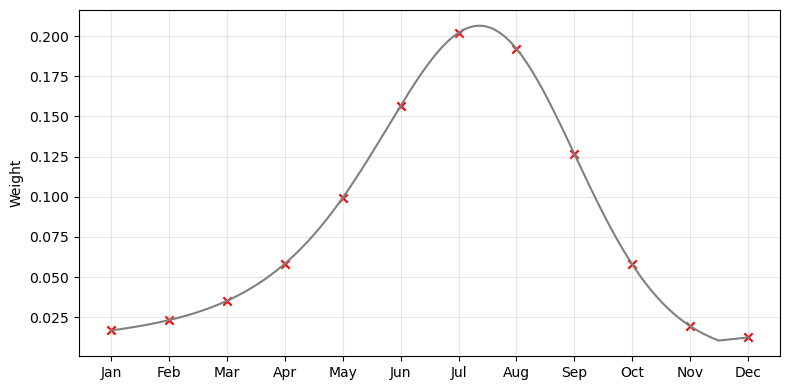

In [42]:
result = fit_skewed_month_weights(
    models,
    crossing_big_dict,
    paleo_big_dict,
    mu0=6.0,
    sigma0=4.0,
    skew0=0.0,
    kurt0=2.0,
    model_weights=model_weights
)

print("Success:", result['success'])
print("Message:", result['message'])
print("Best-fit mu   :", result['mu'])
print("Best-fit sigma:", result['sigma'])
print("Best-fit skew :", result['skew'])
print("Best-fit kurt :", result['kurt'])
print("Best-fit weights:")
print(result['weights'])
print("RMSE to 1:1 line:", result['rmse_1to1'])
print("Regression slope:", result['regression_slope'])
print("Regression intercept:", result['regression_intercept'])
print("Regression R^2:", result['regression_r2'])

plot_fitted_weights(result)


Success: True
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Best-fit mu   : 6.000000093480889
Best-fit sigma: 3.282155011284302
Best-fit skew : -0.6172342222468087
Best-fit kurt : 2.0
Best-fit weights:
[0.04800961 0.08436623 0.12316448 0.14725104 0.14625396 0.1254953
 0.09813689 0.07377967 0.05545425 0.04227144 0.03221461 0.02360252]
RMSE to 1:1 line: 0.583721968969104
Regression slope: 1.0495590201154708
Regression intercept: -0.1903952293653586
Regression R^2: 0.2681812252984802


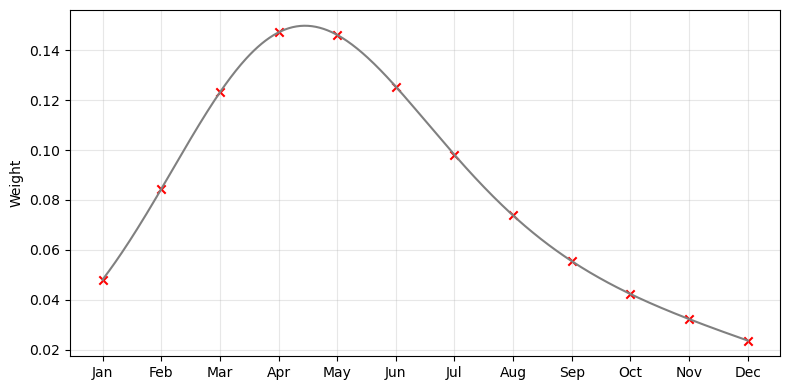

In [43]:
result2 = fit_skewed_month_weights(
    models,
    crossing2_big_dict,
    paleo2_big_dict,
    mu0=6.0,
    sigma0=4.0,
    skew0=0.0,
    kurt0=2.0,
    model_weights=model_weights
)

print("Success:", result2['success'])
print("Message:", result2['message'])
print("Best-fit mu   :", result2['mu'])
print("Best-fit sigma:", result2['sigma'])
print("Best-fit skew :", result2['skew'])
print("Best-fit kurt :", result2['kurt'])
print("Best-fit weights:")
print(result2['weights'])
print("RMSE to 1:1 line:", result2['rmse_1to1'])
print("Regression slope:", result2['regression_slope'])
print("Regression intercept:", result2['regression_intercept'])
print("Regression R^2:", result2['regression_r2'])

plot_fitted_weights(result2)

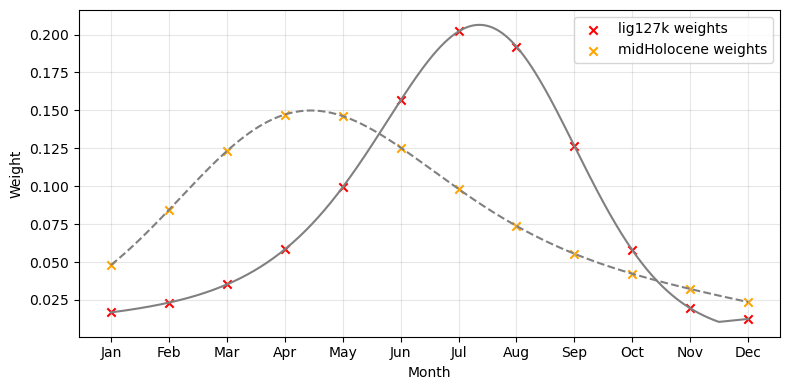

In [44]:

lig_127k_weights = result['weights']

lig_127k_weights_fine = skewed_gaussian_month_weights(result['mu'], result['sigma'], result['skew'], kurt=2.0, x=np.linspace(1, 12, 500))
lig_127k_weights_fine = lig_127k_weights_fine * lig_127k_weights[0] / lig_127k_weights_fine[0]

midHolocene_weights = result2['weights']

midHolocene_weights_fine = skewed_gaussian_month_weights(result2['mu'], result2['sigma'], result2['skew'], kurt=2.0, x=np.linspace(1, 12, 500))
midHolocene_weights_fine = midHolocene_weights_fine * midHolocene_weights[0] / midHolocene_weights_fine[0]
plt.figure(figsize=(8, 4))
plt.scatter(np.arange(1, 13), lig_127k_weights, label='lig127k weights', marker='x', color='red')
plt.scatter(np.arange(1, 13), midHolocene_weights, label='midHolocene weights', marker='x', color='orange')
plt.plot(np.linspace(1, 12, 500), lig_127k_weights_fine, color='grey')
plt.plot(np.linspace(1, 12, 500), midHolocene_weights_fine, color='grey', linestyle='--')
plt.xticks(np.arange(1, 13), months)
plt.xlabel('Month')
plt.ylabel('Weight')
#plt.title('Comparison of Fitted Monthly Weights')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [45]:

flat_weights = np.array([1/12]*12)
crossing_vals_flat, paleo_vals_flat, model_names = calculate_model_energies(
        flat_weights, models, crossing_big_dict, paleo_big_dict
    )

In [46]:
result_flat = result.copy()
result_flat['weights'] = flat_weights
result_flat['crossing_vals'] = crossing_vals_flat
result_flat['paleo_vals'] = paleo_vals_flat

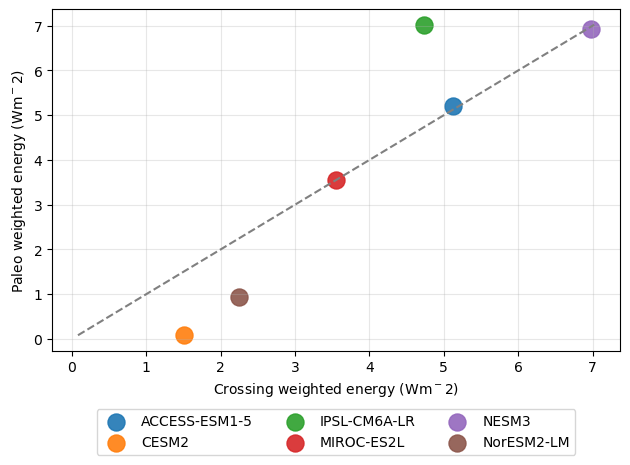

In [47]:
plot_crossing_vs_paleo(result, model_weights)

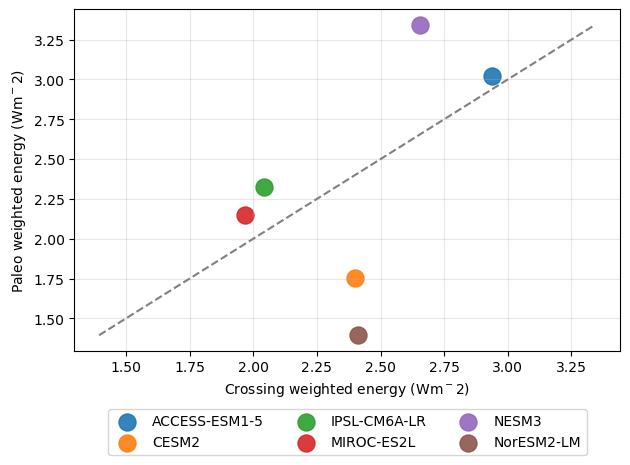

In [48]:
plot_crossing_vs_paleo(result2, model_weights)

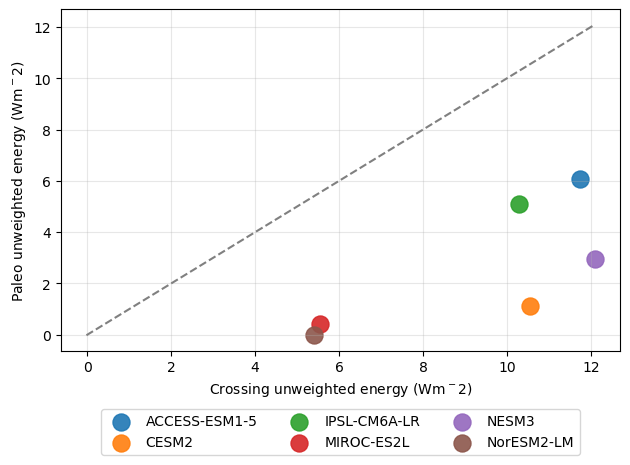

In [49]:
plot_crossing_vs_paleo(result_flat, model_weights, label='unweighted')



In [50]:
plot_big_dict = crossing_big_dict
month_weights = result['weights']
weighted_energy_mmm = None
plt.figure(figsize=(8, 4))
for model in models:


    weighted_energy = month_weights * (plot_big_dict[model]['rsds'].data + plot_big_dict[model]['rlds'].data)
    #print(crossing_weighted_energy)

    if weighted_energy_mmm is None:
        weighted_energy_mmm = weighted_energy
    else:
        weighted_energy_mmm += weighted_energy
    plt.plot(weighted_energy, label=f'{model}', linestyle='--')
plt.plot(weighted_energy_mmm / len(models), label='Crossing MMM', color='black', linestyle='-')
plt.grid(True)
plt.xlim(0, 11)
plt.xticks(np.arange(12), months)
plt.ylabel('Weighted Energy Flux Anomaly (Wm$^{-2}$)')
#legend outside of plot
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.title('Crossing Point')
plt.show()

KeyError: 'rsds'

<Figure size 800x400 with 0 Axes>

In [ ]:
plot_big_dict = paleo_big_dict
month_weights = result['weights']
weighted_energy_mmm = None
plt.figure(figsize=(8, 4))
for model in models:


    weighted_energy = month_weights * (plot_big_dict[model]['anom_clim']['rsds'].data + plot_big_dict[model]['anom_clim']['rlds'].data)
    #print(crossing_weighted_energy)

    if weighted_energy_mmm is None:
        weighted_energy_mmm = weighted_energy
    else:
        weighted_energy_mmm += weighted_energy
    plt.plot(weighted_energy, label=f'{model} Crossing', linestyle='--')
plt.plot(weighted_energy_mmm / len(models), label='Crossing MMM', color='black', linestyle='-')
plt.grid(True)
plt.xlim(0, 11)
plt.xticks(np.arange(12), months)
plt.ylabel('Weighted Energy Flux Anomaly (Wm$^{-2}$)')
plt.title('lig127k')
plt.show()

In [ ]:
plt.figure(figsize=(10,6))
for model in models:
    crossing_weighted = np.dot(month_weights, (crossing_big_dict[model]['rsds'].data + crossing_big_dict[model]['rlds'].data))
    paleo_weighted = np.dot(month_weights, (paleo_big_dict[model]['anom_clim']['rsds'].data + paleo_big_dict[model]['anom_clim']['rlds'].data))

    crossing_sia = crossing_big_dict[model]['siconc'].extract(iris.Constraint(month=transient_month)).data / 1e14
    paleo_sia = paleo_big_dict[model]['anom_clim']['siconc'].extract(iris.Constraint(month=paleo_month)).data / 1e14

    # print(model)
    # print(f"  Crossing weighted energy: {crossing_weighted:.3f} Wm$^{{-2}}$")
    # print(f"  Paleo weighted energy: {paleo_weighted:.3f} Wm$^{{-2}}$")
    # print(f"  Crossing SIA: {crossing_sia:.2f} Mkm²")
    # print(f"  Paleo SIA: {paleo_sia:.2f} Mkm²")
    plt.scatter(crossing_weighted, crossing_sia, label=f'{model} Crossing', marker='o', s=150*model_weight_dict[model], alpha=0.9)
    plt.scatter(paleo_weighted, paleo_sia, label=f'{model} Paleo', marker='x', s=150*model_weight_dict[model], alpha=0.9)
plt.xlabel('Weighted Energy Flux Anomaly (Wm$^{-2}$)')
plt.ylabel('Sea Ice Area (million km²)')
plt.title('Model Comparison of Weighted Energy vs SIA')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:

def log_prior(mu, sigma, skew, log_obs_sigma):
    if not (1.0 <= mu <= 12.0):
        return -np.inf
    if not (0.2 <= sigma <= 12.0):
        return -np.inf
    if not (-2.0 <= skew <= 2.0):
        return -np.inf
    if not (-7.0 <= log_obs_sigma <= 5.0):
        return -np.inf

    lp_skew = -0.5 * (skew / 0.75) ** 2
    lp_sigma = -0.5 * ((sigma - 3.0) / 3.0) ** 2

    # Prior on obs_sigma: centred around 0.25, with moderate spread in log space
    lp_log_obs_sigma = -0.5 * ((log_obs_sigma - np.log(0.25)) / 0.5) ** 2

    return lp_skew + lp_sigma + lp_log_obs_sigma


def log_likelihood(mu, sigma, skew, log_obs_sigma, models, crossing_big_dict, paleo_big_dict):
    obs_sigma = np.exp(log_obs_sigma)

    weights = skewed_gaussian_month_weights(mu, sigma, skew)
    if weights is None:
        return -np.inf

    crossing_vals, paleo_vals, _ = calculate_model_energies(
        weights, models, crossing_big_dict, paleo_big_dict
    )

    diff = paleo_vals - crossing_vals
    n = diff.size

    ll = -0.5 * np.sum((diff / obs_sigma) ** 2) - n * np.log(obs_sigma) - 0.5 * n * np.log(2 * np.pi)
    return ll


def log_posterior(params, models, crossing_big_dict, paleo_big_dict):
    mu, sigma, skew, log_obs_sigma = params

    lp = log_prior(mu, sigma, skew, log_obs_sigma)
    if not np.isfinite(lp):
        return -np.inf

    ll = log_likelihood(mu, sigma, skew, log_obs_sigma, models, crossing_big_dict, paleo_big_dict)
    if not np.isfinite(ll):
        return -np.inf

    return lp + ll


def run_mcmc(
    models,
    crossing_big_dict,
    paleo_big_dict,
    start=(6.0, 4.0, 0.0, 0.0),  # last entry is log_obs_sigma
    n_steps=30000,
    proposal_scales=(0.15, 0.12, 0.05, 0.08),
    random_seed=42,
):
    rng = np.random.default_rng(random_seed)

    chain = np.zeros((n_steps, 4))
    logpost = np.zeros(n_steps)

    current = np.array(start, dtype=float)
    current_lp = log_posterior(current, models, crossing_big_dict, paleo_big_dict)

    if not np.isfinite(current_lp):
        raise ValueError("Initial parameter set has non-finite posterior.")

    chain[0] = current
    logpost[0] = current_lp

    n_accept = 0

    for i in range(1, n_steps):
        proposal = current + rng.normal(0.0, proposal_scales, size=4)
        proposal_lp = log_posterior(proposal, models, crossing_big_dict, paleo_big_dict)

        log_alpha = proposal_lp - current_lp

        if np.log(rng.uniform()) < log_alpha:
            current = proposal
            current_lp = proposal_lp
            n_accept += 1

        chain[i] = current
        logpost[i] = current_lp

    accept_rate = n_accept / (n_steps - 1)
    return chain, logpost, accept_rate

def summarise_posterior(chain, burn=5000, thin=10):
    """
    Return posterior samples after burn-in and thinning.
    """
    samples = chain[burn::thin]
    summary = {
        "mu_mean": np.mean(samples[:, 0]),
        "mu_std": np.std(samples[:, 0]),
        "sigma_mean": np.mean(samples[:, 1]),
        "sigma_std": np.std(samples[:, 1]),
        "skew_mean": np.mean(samples[:, 2]),
        "skew_std": np.std(samples[:, 2]),
        "obs_sigma_mean": np.mean(samples[:, 3]),
        "obs_sigma_std": np.std(samples[:, 3]),
        "samples": samples,
    }
    return summary


def posterior_weight_samples(samples):
    """
    Convert posterior parameter samples into weight samples.
    """
    weight_list = []

    for mu, sigma, skew, _ in samples:
        w = skewed_gaussian_month_weights(mu, sigma, skew)
        if w is not None:
            weight_list.append(w)

    return np.asarray(weight_list)


def plot_chain(chain, burn=0):
    labels = ["mu", "sigma", "skew", "obs_sigma"]
    fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

    for j in range(4):
        axes[j].plot(chain[:, j], lw=0.5)
        if burn > 0:
            axes[j].axvline(burn, ls='--')
        axes[j].set_ylabel(labels[j])

    axes[-1].set_xlabel("Step")
    plt.tight_layout()
    plt.show()


def plot_posterior_weights(weight_samples):
    month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    w_mean = np.mean(weight_samples, axis=0)
    w_lo = np.percentile(weight_samples, 5, axis=0)
    w_hi = np.percentile(weight_samples, 95, axis=0)

    plt.figure(figsize=(8, 4))
    plt.plot(month_labels, w_mean, marker='o')
    plt.fill_between(month_labels, w_lo, w_hi, alpha=0.3)
    plt.ylabel("Weight")
    plt.title("Posterior monthly weights (mean and 90% interval)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_posterior_crossing_vs_paleo(samples, models, crossing_big_dict, paleo_big_dict):
    """
    Use posterior mean parameters to plot crossing vs paleo.
    """
    mu_mean = np.mean(samples[:, 0])
    sigma_mean = np.mean(samples[:, 1])
    skew_mean = np.mean(samples[:, 2])

    weights = skewed_gaussian_month_weights(mu_mean, sigma_mean, skew_mean)

    crossing_vals, paleo_vals, model_names = calculate_model_energies(
        weights, models, crossing_big_dict, paleo_big_dict
    )

    plt.figure(figsize=(6, 6))
    plt.scatter(crossing_vals, paleo_vals)

    for name, x, y in zip(model_names, crossing_vals, paleo_vals):
        plt.annotate(name, (x, y), textcoords='offset points', xytext=(5, 5), ha='left')

    min_val = min(np.min(crossing_vals), np.min(paleo_vals))
    max_val = max(np.max(crossing_vals), np.max(paleo_vals))
    plt.plot([min_val, max_val], [min_val, max_val], '--', color='gray')

    plt.xlabel("Crossing weighted energy")
    plt.ylabel("Paleo weighted energy")
    plt.title("Crossing vs paleo using posterior mean parameters")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
chain, logpost, accept_rate = run_mcmc(
    models,
    crossing_big_dict,
    paleo_big_dict,
    start=(6.0, 4.0, 0.0, 0.25),
    n_steps=30000,
    proposal_scales=(0.15, 0.12, 0.06, 0.08),
    random_seed=42,
)

print("Acceptance rate:", accept_rate)

In [ ]:
plot_chain(chain, burn=5000)

In [ ]:
summary = summarise_posterior(chain, burn=5000, thin=10)

print("mu        :", summary["mu_mean"], "+/-", summary["mu_std"])
print("sigma     :", summary["sigma_mean"], "+/-", summary["sigma_std"])
print("skew      :", summary["skew_mean"], "+/-", summary["skew_std"])
print("obs_sigma :", summary["obs_sigma_mean"], "+/-", summary["obs_sigma_std"])

In [ ]:
weight_samples = posterior_weight_samples(summary["samples"])
plot_posterior_weights(weight_samples)

In [ ]:
plot_posterior_crossing_vs_paleo(
    summary["samples"],
    models,
    crossing_big_dict,
    paleo_big_dict
)

In [ ]:
burn = 5000
best_idx = np.argmax(logpost[burn:])
best_params = chain[burn:][best_idx]

mu_map, sigma_map, skew_map, log_obs_sigma_map = best_params
weights_map = skewed_gaussian_month_weights(mu_map, sigma_map, skew_map)

crossing_map, paleo_map, _ = calculate_model_energies(
    weights_map, models, crossing_big_dict, paleo_big_dict
)

rmse_map = np.sqrt(np.mean((crossing_map - paleo_map) ** 2))
print("MAP-like RMSE:", rmse_map)

In [ ]:
samples = chain[burn::10]

weight_samples = []
for mu, sigma, skew, log_obs_sigma in samples:
    w = skewed_gaussian_month_weights(mu, sigma, skew)
    if w is not None:
        weight_samples.append(w)

weight_samples = np.asarray(weight_samples)
weights_post_mean = weight_samples.mean(axis=0)

crossing_pm, paleo_pm, _ = calculate_model_energies(
    weights_post_mean, models, crossing_big_dict, paleo_big_dict
)

rmse_pm = np.sqrt(np.mean((crossing_pm - paleo_pm) ** 2))
print("Posterior-mean-weight RMSE:", rmse_pm)

In [ ]:
#EC-Earth3 failed to download, try new wget from a different location